**Chapter 10 – Introduction to Artificial Neural Networks with Keras**

This chapter introduces artificial neural networks (ANNs), focusing on their biological inspiration, key concepts like perceptrons and activation functions, and practical implementation using Keras for classification and regression tasks. You'll build, train, and evaluate models on datasets like Fashion MNIST and California housing, exploring both sequential and functional APIs. By the end, you'll understand how to construct and fine-tune neural networks for real-world problems.

_This notebook contains all the sample code and solutions to the exercises in chapter 10._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [9]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [10]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [11]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [12]:
print("tensorflow version:", tf.__version__)

tensorflow version: 2.19.1


As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [13]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/ann` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [14]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---
# From Biological to Artificial Neurons

Artificial neural networks (ANNs) draw inspiration from the biological neurons in the human brain. In this section, we'll explore the fundamental concepts of biological neurons, how they process information, and how these ideas have been adapted to create artificial neurons. This biological foundation will help us understand the building blocks of ANNs, including key components like perceptrons, activation functions, and the evolution toward more complex models. By bridging biology and computation, we'll set the stage for implementing powerful machine learning algorithms.

## The Perceptron

The perceptron is one of the simplest forms of an artificial neuron, inspired by biological neurons. It takes multiple binary inputs $x_i$, applies weights $w_i$ to them, sums the weighted inputs, and passes the result through an activation function (typically a step function) to produce a binary output ($y = 0$ or $1$). Mathematically, for inputs $x_1, x_2, \dots, x_n$ and weights $w_1, w_2, \dots, w_n$, the output $y$ is:

$$
y = \begin{cases} 
1 & \text{if } \sum_{i=1}^n w_i x_i + b > 0 \
0 & \text{otherwise}
\end{cases}
$$

where $b$ is the bias term. The perceptron can learn linearly separable patterns through training, adjusting weights using the perceptron learning rule. However, it cannot handle non-linear problems like XOR. In the code below, we train a perceptron on the Iris dataset to classify Iris setosa based on petal length and width, demonstrating its decision boundary.

In [7]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

# Load the Iris dataset as a pandas DataFrame for easier column selection
iris = load_iris(as_frame=True)

# Extract petal length and width as features (X) for binary classification
X = iris.data[["petal length (cm)", "petal width (cm)"]].values

# Create binary target: True for Iris setosa (class 0), False otherwise
y = (iris.target == 0)  # Iris setosa

# Initialize a Perceptron classifier with a fixed random state for reproducibility
per_clf = Perceptron(random_state=42)

# Train the perceptron on the features X and targets y
per_clf.fit(X, y)

# Define new samples to predict: [petal length, petal width]
X_new = [[2, 0.5], [3, 1]]

# Predict whether these new samples are Iris setosa (True) or not (False)
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

In the preceding code cell, we implement a simple perceptron classifier using Scikit-Learn's `Perceptron` class. We load the Iris dataset, select features (petal length and width), and create a binary target for classifying Iris setosa (True if target == 0). The perceptron is trained on this data, and we make predictions on new samples `X_new = [[2, 0.5], [3, 1]]`, resulting in `y_pred` indicating whether each flower is predicted as setosa or not. This demonstrates the perceptron's ability to learn a linear decision boundary for separable classes.

In [8]:
y_pred

array([ True, False])

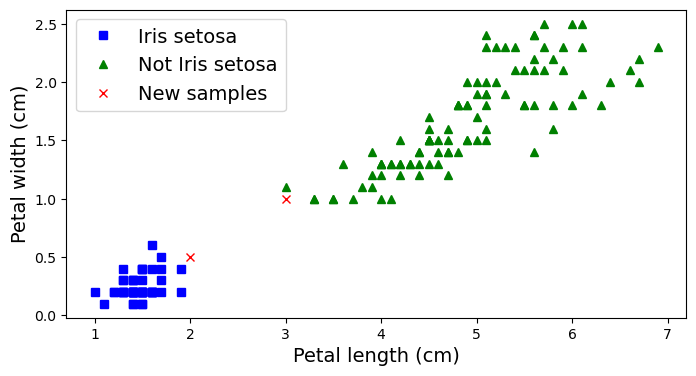

In [9]:
import matplotlib.pyplot as plt

# Visualize the training data and the new samples with different markers
plt.figure(figsize=(8, 4))
plt.plot(X[y == True][:, 0], X[y == True][:, 1], "bs", label="Iris setosa")
plt.plot(X[y == False][:, 0], X[y == False][:, 1], "g^", label="Not Iris setosa")
plt.plot(np.array(X_new)[:, 0], np.array(X_new)[:, 1], "rx", label="New samples")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend()
plt.show()

The `Perceptron` is equivalent to a `SGDClassifier` with `loss="perceptron"`, no regularization, and a constant learning rate equal to 1:

In [10]:
# extra code – shows how to build and train a Perceptron

from sklearn.linear_model import SGDClassifier

# Build an equivalent SGDClassifier with perceptron loss to verify identical behavior
sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)

# Verify that both classifiers have the same coefficients and intercepts
assert (sgd_clf.coef_ == per_clf.coef_).all(), "Coefficients do not match!"
assert (sgd_clf.intercept_ == per_clf.intercept_).all(), "Intercepts do not match!"

When the Perceptron finds a decision boundary that properly separates the classes, it stops learning. This means that the decision boundary is often quite close to one class:

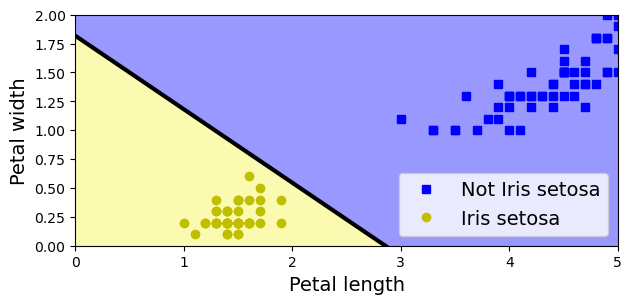

In [11]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset
from matplotlib.colors import ListedColormap

# Calculate the slope (a) and intercept (b) of the decision boundary
a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]

# Create a mesh grid to plot the decision boundary
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

# Plot the decision boundary along with the training data
plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

The decision boundary in the figure represents the linear separator learned by the Perceptron classifier on the Iris dataset, distinguishing Iris setosa (yellow dots) from the other species (blue squares) based on petal length and width. The black line is the hyperplane defined by the equation $\sum w_i x_i + b = 0$, where the weights $w$ and bias $b$ are derived from the trained model. 

Points below and to the left of the black line are classified as Iris setosa (yellow dots), while those above and to the right are not (blue squares). This matches the orientation of the decision boundary as plotted by the Perceptron on these features. This boundary is linear and effectively separates the linearly separable classes in this 2D feature space, though it may not generalize well to non-linear problems like XOR. The shaded regions (light blue and yellow) illustrate the classification areas for visualization.

---

## Activation Functions

**Activation functions** introduce nonlinearity into neural networks by transforming a layer's pre-activation (the weighted sum plus bias) into its output. This nonlinearity allows deep networks to learn complex, non‑linear patterns. Common activation functions include:

- **Step (Heaviside) function**: Outputs 0 or 1 depending on whether the input is below or above a threshold. Used in early perceptrons.
- **Sigmoid**: Maps input to (0, 1). Useful for binary classification, but can saturate and cause vanishing gradients.
- **Hyperbolic tangent (tanh)**: Maps input to (−1, 1). Zero-centered but can also saturate.
- **Rectified Linear Unit (ReLU)**: Outputs max(0, x). Helps mitigate vanishing gradients, but neurons can “die” if they only output zero.
- **Leaky ReLU / ELU**: Variants of ReLU that allow a small, non-zero gradient when the unit is not active, helping prevent dead neurons.
- **Softmax**: Used in output layers for multiclass classification, converts logits to a probability distribution.
    - it converts raw scores (logits) into probabilities by exponentiating them and normalizing by the sum of all exponentiated scores.
- **Linear activation**: Used in regression output layers, passes the input through unchanged.

Each activation has different properties that affect gradient flow and learning dynamics. The code below visualizes these activation functions and their derivatives to illustrate their behavior and impact on training.

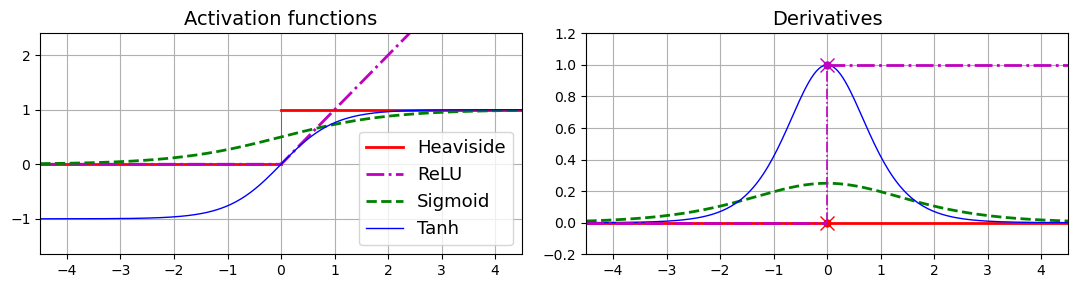

In [12]:
# extra code – this cell generates and saves Figure 10–8

from scipy.special import expit as sigmoid

def relu(z):
    """
    Applies the Rectified Linear Unit (ReLU) activation function.

    Args:
        z (array-like): Input array or scalar.

    Returns:
        array-like: Output where each element is max(0, z).
    """
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    """
    Computes the numerical derivative of a function at given points.

    Args:
        f (callable): The function whose derivative is to be computed.
        z (array-like or float): Points at which to compute the derivative.
        eps (float, optional): Small value for finite differences. Defaults to 0.000001.

    Returns:
        array-like or float: The numerical derivative of f at z.
    """
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

# Plot activation functions
plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

# Plot derivatives of activation functions
plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

The figure above illustrates common activation functions used in neural networks, along with their derivatives, to highlight their behavior and impact on gradient flow during training.

- **Left subplot (Activation Functions)**: Plots the functions over the range [-4.5, 4.5]. The Heaviside (step) function is binary (0 or 1), ReLU is linear for positive inputs and zero otherwise, Sigmoid maps to (0,1) with an S-shape, and Tanh maps to (-1,1) centered at zero. These introduce nonlinearity, enabling networks to learn complex patterns.

- **Right subplot (Derivatives)**: Shows the derivatives, which indicate gradient magnitudes. Heaviside has zero gradient everywhere except at zero (discontinuous), ReLU has a gradient of 1 for positive inputs and 0 otherwise (can cause "dead" neurons), Sigmoid and Tanh have bell-shaped gradients that vanish for large inputs (vanishing gradients problem).

This visualization helps compare how each function handles inputs and gradients, guiding choices like ReLU for deep networks to mitigate vanishing gradients.

---
## Regression MLPs

**Regression MLPs (Multi-Layer Perceptrons)** are powerful neural network models capable of learning complex, non-linear relationships in regression tasks. Unlike classification MLPs, which predict discrete class labels, regression MLPs output continuous values, making them suitable for problems such as predicting house prices or stock values. In this section, we'll explore how to build, train, and evaluate regression MLPs using Scikit-Learn and Keras, and discuss best practices for preprocessing data and assessing model performance.

**Warning**: In recent versions of Scikit-Learn, you must use `root_mean_squared_error()` to compute the RMSE, instead of `mean_squared_error(labels, predictions, squared=False)`. The following `try`/`except` block tries to import `root_mean_squared_error`, and if it fails it just defines it.

In [13]:
try:
    from sklearn.metrics import root_mean_squared_error
    print("Using sklearn's root_mean_squared_error")
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        """ Calculates the Root Mean Squared Error (RMSE) between true labels and predictions."""
        return mean_squared_error(labels, predictions, squared=False)

In this section, we use Scikit-Learn's `MLPRegressor` to build a multi-layer perceptron for regression on the California housing dataset. The data is split into training, validation, and test sets. We standardize the features using `StandardScaler` and train an MLP with three hidden layers of 50 neurons each. The model's performance is evaluated using the Root Mean Squared Error (RMSE) on the validation set.

In [14]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Load California housing dataset and split into training, validation, and test sets
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)
print(f"Train set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_valid.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Train a Multi-Layer Perceptron regressor with three hidden layers of 50 neurons each
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg) # pipeline with standardization
pipeline.fit(X_train, y_train) # train the model

# Make predictions on the validation set and compute RMSE
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

Train set size: 11610 samples
Validation set size: 3870 samples
Test set size: 5160 samples


In [15]:
rmse

0.505332665796865

Corresponding to the house prices in `y_valid`, the Root Mean Squared Error (RMSE) is the square root of the mean squared prediction error:
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (\hat y_i - y_i)^2}$$
It measures the typical magnitude of prediction errors in the same units as the target values.

In practice this means that an RMSE of, say, $0.5$ should be read in the dataset's units (if `y` is in units of \$100,000, then RMSE = $0.5$ corresponds to an average error of \$50,000). To judge whether an RMSE is acceptable, compare it to the typical house price scale (mean or range of `y_valid`) or convert it to a relative metric, e.g. $$\text{relative RMSE} = \frac{\text{RMSE}}{\overline{y_{\text{valid}}}},$$ which gives a percentage error.

Note that RMSE penalizes large errors more than small ones (due to squaring), so it is sensitive to outliers; inspect residuals and consider alternative metrics (MAE, percentile errors) or modeling changes (features, regularization) if RMSE is large.

In [16]:
y_valid.max(), y_valid.min()

(5.00001, 0.14999)

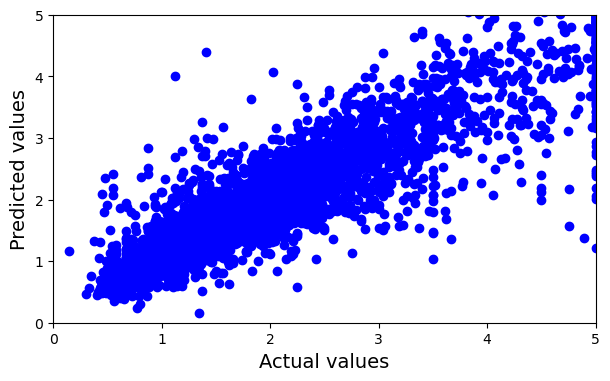

In [17]:
plt.figure(figsize=(7,4))
plt.plot(y_valid, y_pred, "bo")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.axis([0, 5, 0, 5])
plt.show()

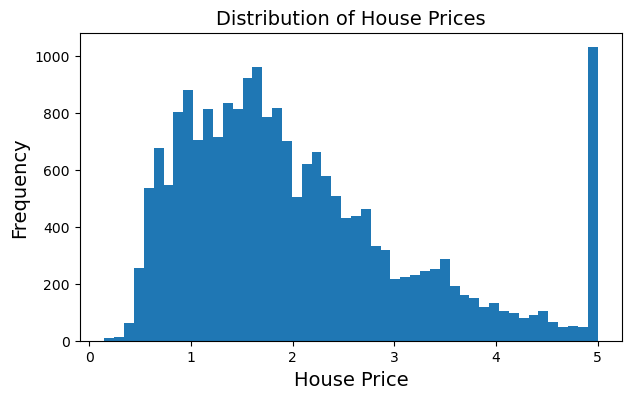

In [18]:
plt.figure(figsize=(7,4))
plt.hist(housing.target, bins=50)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

In [19]:
# verify the test set performance
y_test_pred = pipeline.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
print(f"Test RMSE: {rmse_test}")

Test RMSE: 0.5211279195573619


---
## Classification MLPs

This section shows two common ways to build MLP classifiers.

- For small tabular datasets we often use Scikit‑Learn's `MLPClassifier`. The short exercise below demonstrates loading the Iris dataset as NumPy arrays using `load_iris(return_X_y=True)` (which avoids `.data`/`.target` type-checking ambiguities), splitting the data with `stratify=y` to preserve class balance, wrapping an `MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000, random_state=42)` in a `Pipeline` with `StandardScaler()`, fitting it, and reporting validation accuracy.

- For larger image datasets we use Keras. For example, with Fashion MNIST we scale pixel values to the [0, 1] range, build a sequential MLP with two hidden layers (300 and 100 units, ReLU) and a softmax output for multiclass classification, compile with an optimizer such as Adam and an appropriate loss (e.g., categorical cross-entropy or sparse categorical cross-entropy), then train and evaluate the model on a test set.

Tips: use `stratify` on splits to preserve class proportions and set a reasonably large `max_iter` for Scikit‑Learn MLPs so they can converge on small datasets.

In [20]:
# extra code – this was left as an exercise for the reader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Explicitly get arrays, so the type checker knows X and y are arrays
X, y = load_iris(return_X_y=True)

# Split the dataset into training, validation, and test sets with stratification
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

# Train a Multi-Layer Perceptron classifier with one hidden layer of 5 neurons
mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)

# Evaluate the classifier on the validation set
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

In [21]:
np.array(y_valid), pipeline.predict(X_valid) # Check predictions on validation set

(array([2, 1, 2, 1, 2, 0, 0, 2, 2, 0, 1, 1, 0, 1]),
 array([2, 1, 2, 1, 2, 0, 0, 2, 2, 0, 1, 1, 0, 1]))

In [22]:
# Evaluate the classifier on the test set
print(pipeline.score(X_test, y_test))

# Check predictions on the test set
np.array(y_test), pipeline.predict(X_test)

1.0


(array([1, 2, 2, 1, 2, 0, 0, 0, 2, 1, 0, 2, 1, 1, 0]),
 array([1, 2, 2, 1, 2, 0, 0, 0, 2, 1, 0, 2, 1, 1, 0]))

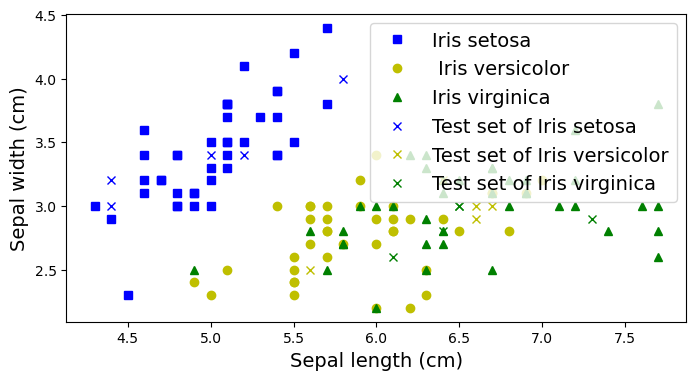

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], "bs", label="Iris setosa")
plt.plot(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], "yo", label=" Iris versicolor")
plt.plot(X_train[y_train == 2][:, 0], X_train[y_train == 2][:, 1], "g^", label="Iris virginica")
plt.plot(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], "bx", label="Test set of Iris setosa")
plt.plot(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], "yx", label="Test set of Iris versicolor")
plt.plot(X_test[y_test == 2][:, 0], X_test[y_test == 2][:, 1], "gx", label="Test set of Iris virginica")
plt.ylabel("Sepal width (cm)")
plt.xlabel("Sepal length (cm)") 
plt.legend()
plt.show()


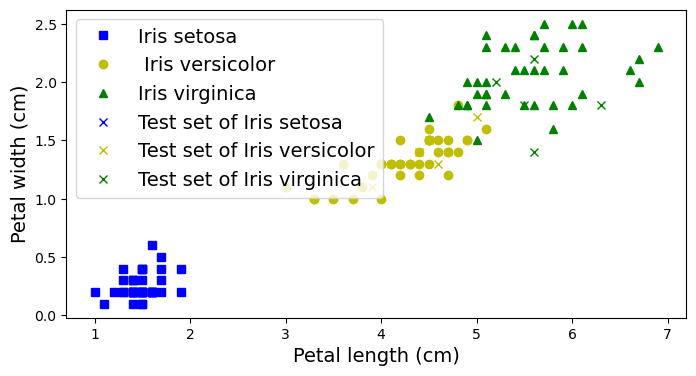

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(X_train[y_train == 0][:, 2], X_train[y_train == 0][:, 3], "bs", label="Iris setosa")
plt.plot(X_train[y_train == 1][:, 2], X_train[y_train == 1][:, 3], "yo", label=" Iris versicolor")
plt.plot(X_train[y_train == 2][:, 2], X_train[y_train == 2][:, 3], "g^", label="Iris virginica")
plt.plot(X_test[y_test == 0][:, 2], X_test[y_test == 0][:, 3], "bx", label="Test set of Iris setosa")
plt.plot(X_test[y_test == 1][:, 2], X_test[y_test == 1][:, 3], "yx", label="Test set of Iris versicolor")
plt.plot(X_test[y_test == 2][:, 2], X_test[y_test == 2][:, 3], "gx", label="Test set of Iris virginica")
plt.ylabel("Petal width (cm)")
plt.xlabel("Petal length (cm)") 
plt.legend()
plt.show()

The two figures visualize the Iris dataset's training and test sets, highlighting class separability across different feature pairs.

- **Figure 1 (Sepal Length vs. Sepal Width)**: Shows moderate overlap between classes, especially versicolor and virginica, indicating sepal features alone may not fully distinguish them. Setosa is clearly separated, aligning with the perceptron's earlier success on petal features.

- **Figure 2 (Petal Length vs. Petal Width)**: Demonstrates better class separation, with setosa isolated and versicolor/virginica more distinct. This supports using petal measurements for classification, as seen in the perceptron example, and explains the MLP's high accuracy on these features. Test points (marked with 'x') align well with training distributions, suggesting good generalization.

---
# Implementing MLPs with Keras

This section demonstrates how to build, train, and evaluate **Multi-Layer Perceptrons (MLPs)** for image classification using Keras. We'll use the Fashion MNIST dataset, which consists of 28×28 grayscale images of clothing items, to illustrate the end-to-end workflow: loading and preprocessing data, constructing the neural network with the Sequential API, compiling the model, and training it to achieve high accuracy.

## Building an Image Classifier Using the Sequential API

In this sub-section, we'll walk through the process of creating a neural network for image classification using **Keras's Sequential API**. This approach allows us to *stack layers* in a straightforward manner, making it easy to define and experiment with different architectures. We'll cover data preparation, model construction, and provide insights into each step of the workflow.


### Using Keras to load the dataset

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in `tf.keras.datasets`. The dataset is already split for you between a training set (60,000 images) and a test set (10,000 images), but it can be useful to split the training set further to have a validation set. We'll use 55,000 images for training, and 5,000 for validation.

In [1]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

The training set contains 60,000 grayscale images, each 28x28 pixels:

In [2]:
X_train.shape

(55000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [3]:
X_train.dtype

dtype('uint8')

Let's scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255:

In [4]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

You can plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

In [5]:
# extra code
plt.figure(figsize=(28/plt.rcParams["figure.dpi"], 28/plt.rcParams["figure.dpi"]))  # 28×28 pixels
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

NameError: name 'plt' is not defined

The labels are the class IDs (represented as uint8), from 0 to 9:

In [ ]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

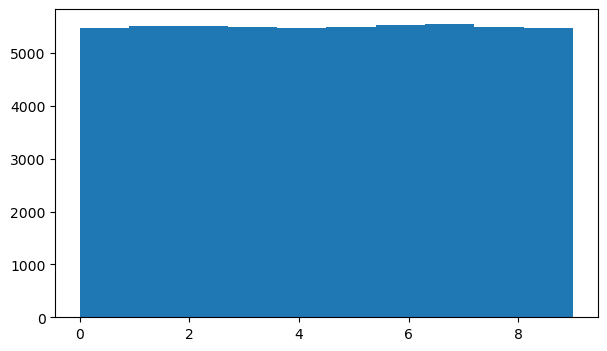

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(y_train, bins=10) # show the distribution of labels in the training set
plt.show()

Here are the corresponding class names:

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

So the first image in the training set is an ankle boot:

In [ ]:
y_train[0] # shows label for first training image

9

In [ ]:
class_names[y_train[0]] # shows class name for first training image

'Ankle boot'

Let's take a look at a sample of the images in the dataset:

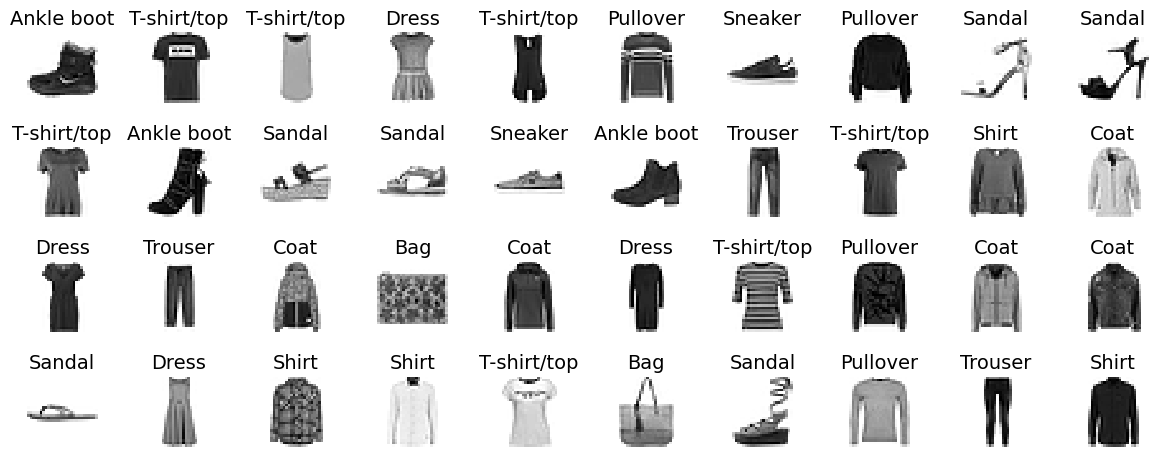

In [ ]:
# extra code – this cell generates and saves Figure 10–10

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("fashion_mnist_plot")
plt.show()

---
### Creating the model using the Sequential API

We can create a neural network model using Keras's Sequential API. A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor.

In [ ]:
from numpy import shape


tf.random.set_seed(42)  # Set the random seed for reproducibility

model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
model.summary() # shows a summary of the model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In the preceding code cell, we create a Sequential neural network model using Keras by explicitly adding layers one at a time. Here's the syntax breakdown:

- `tf.random.set_seed(42)`: Sets the random seed for reproducibility of results
- `model = tf.keras.Sequential()`: Initializes an empty Sequential model container
- `model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))`: Explicitly defines the input layer, specifying that each input will be a 28×28 array (matching the Fashion MNIST image dimensions)
- `model.add(tf.keras.layers.Flatten())`: Adds a Flatten layer that converts the 2D 28×28 input into a 1D array of 784 elements
- `model.add(tf.keras.layers.Dense(300, activation="relu"))`: Adds the first hidden Dense (fully connected) layer with 300 neurons and ReLU activation function
- `model.add(tf.keras.layers.Dense(100, activation="relu"))`: Adds the second hidden Dense layer with 100 neurons and ReLU activation
- `model.add(tf.keras.layers.Dense(10, activation="softmax"))`: Adds the output Dense layer with 10 neurons (one per class) and softmax activation for multi-class probability distribution

This approach builds the model layer-by-layer using the `add()` method. An alternative, more concise syntax is shown in the cell below, where all layers are passed as a list to `tf.keras.Sequential()` at initialization.

In [ ]:
# extra code – clear the session to reset the name counters
from numpy import shape


tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

- Calls `tf.keras.backend.clear_session()` to reset Keras' global state (clears old models/graphs and resets automatic layer-name counters).
- Sets the TF random seed for reproducibility: `tf.random.set_seed(42)`.
- Builds a Sequential model in the concise form by passing a list of layers:
    - `tf.keras.layers.InputLayer(shape=[28, 28])` (explicit input layer),
    - `tf.keras.layers.Flatten()`,
    - `tf.keras.layers.Dense(300, activation="relu")`,
    - `tf.keras.layers.Dense(100, activation="relu")`,
    - `tf.keras.layers.Dense(10, activation="softmax")`.

Difference vs the previous cell:

- The previous cell added layers one by one using `model = tf.keras.Sequential()` and `model.add(...)`.
- This cell constructs the same architecture by passing the layers as a list directly to `tf.keras.Sequential()` (note: you could also pass the input shape to the first layer, e.g., `Flatten(input_shape=[28, 28])`, which would implicitly create an input layer).

Functionally the two approaches are equivalent (same layers, shapes, and behavior); the main differences are coding style and the explicit use of `clear_session()` here to reset names/global state before creating the model.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Then, in order to visaulize the model architecture, we can call the `plot_model()` function from the `tf.keras.utils` module. This function generates a graphical representation of the model architecture, showing the layers, their connections, and the shape of the data as it flows through the network.

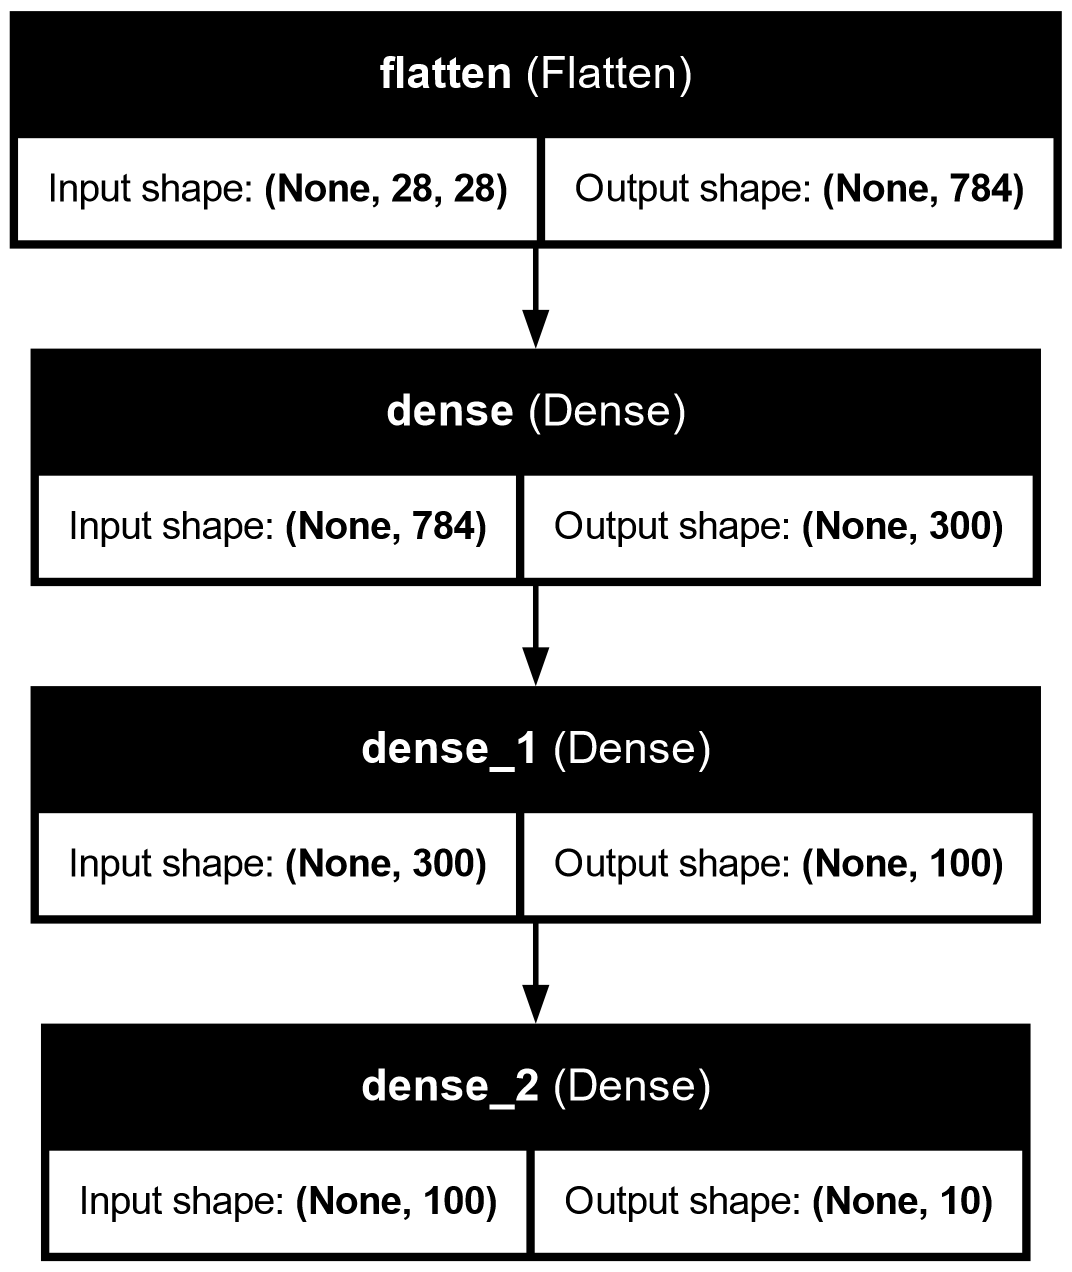

In [ ]:
# extra code – another way to display the model's architecture
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True, show_layer_names=True)

In [ ]:
model.layers # shows the list of layers in the model

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

**Investigating Layers and Weights**

- `hidden1 = model.layers[1]`  
    Selects the layer at index 1 (the first Dense hidden layer; index 0 is the Flatten layer).

- `hidden1.name`  
    Shows the layer's name (e.g., `"dense"`).

- `model.get_layer('dense') is hidden1`  
    Uses `get_layer()` to retrieve the layer by name and checks identity (`is`) to confirm it returns the same object.

- `weights, biases = hidden1.get_weights()`  
    Retrieves the layer parameters:  
    - `weights` is a 2‑D NumPy array shaped (n_inputs, n_neurons)  
    - `biases` is a 1‑D array shaped (n_neurons,)  

These commands let you inspect and manipulate a layer's configuration and learned parameters.

In [ ]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [ ]:
model.get_layer('dense') is hidden1

True

In [ ]:
weights, biases = hidden1.get_weights()
weights

array([[-0.01870957,  0.00505754, -0.0273914 , ...,  0.04080545,
         0.0713421 ,  0.06962739],
       [-0.00501772, -0.07265072,  0.01436058, ...,  0.01472396,
        -0.02595786,  0.05458526],
       [-0.01068371,  0.04001445, -0.06267232, ..., -0.05030619,
        -0.01819253,  0.05572422],
       ...,
       [-0.00257032, -0.03731138,  0.06232202, ..., -0.05861288,
        -0.05456396, -0.00878414],
       [-0.02135235,  0.00082354,  0.03556158, ..., -0.00980061,
        -0.0362212 ,  0.05049603],
       [-0.00259959, -0.01227607,  0.01407585, ...,  0.05143932,
         0.05643901, -0.03610604]], dtype=float32)

In [ ]:
weights.shape

(784, 300)

The `weights` variable contains the weight matrix of the first hidden Dense layer in the model (`model.layers[1]`). 

This matrix has shape `(784, 300)`, 
- where 784 is the number of input features (28×28 pixels flattened)
- 300 is the number of neurons in the layer. 

Each entry `weights[i, j]` represents the connection strength from input feature `i` to neuron `j`. These weights are learned during training and determine how the input pixels influence the activations of the hidden layer.

In [ ]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
biases.shape

(300,)

The perceptron layer in this model is represented by a `Dense` layer with weights and biases:

- **Weights (`weights`)**: This is a matrix of shape `(784, 300)`, where each row corresponds to an input pixel (flattened from the 28×28 image), and each column corresponds to a neuron in the first hidden layer. Each value represents the strength and direction (positive or negative) of the connection between a specific input pixel and a specific neuron.

- **Biases (`biases`)**: This is a vector of length `300`, with one bias term for each neuron in the layer. The bias allows each neuron to shift its activation function independently of the input.

**How the perceptron layer works:**

For each input image (flattened to a vector $x$ of length 784), the perceptron computes:

$$
z_j = \sum_{i=1}^{784} w_{ij} x_i + b_j
$$

where:
- $w_{ij}$ is the weight from input $i$ to neuron $j$
    - $i$ indexes the flattened input pixels, i = 1, 2, ..., 784
    - $j$ indexes the neurons in the layer, j = 1, 2, ..., 300
- $x_i$ is the input pixel value
- $b_j$ is the bias for neuron $j$
- $z_j$ is the pre-activation value for neuron $j$

Furthermore, the computation for all neurons can be expressed in matrix form:
$$z = W^T x + b
$$
where:
- $W$ is the weight matrix of shape (784, 300)
- $b$ is the bias vector of shape (300,)
- $z$ is the resulting vector of pre-activation values for all 300 neurons.

The activation function (ReLU in this case) is then applied:

$$
a_j = \text{ReLU}(z_j)
$$

This process transforms the input image into a new representation, enabling the network to learn complex patterns. The weights and biases are learned during training to minimize the loss and improve classification accuracy.

---

### Compiling the Model

Before training the model, we need to compile it. Compiling the model configures the learning process by specifying the optimizer, loss function, and evaluation metrics. The optimizer determines how the model weights are updated during training, the loss function measures how well the model is performing, and the metrics provide additional insights into the model's performance.


In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

Here, it configures the Keras model's training loop: `loss="sparse_categorical_crossentropy"` tells Keras to use the sparse categorical cross-entropy loss (appropriate when targets are integer class IDs), `optimizer="sgd"` selects stochastic gradient descent, and `metrics=["accuracy"]` asks Keras to report accuracy during training and evaluation.

The loss for sparse categorical cross-entropy for a batch of $n$ examples is
$$\text{Loss} = -\frac{1}{n}\sum_{i=1}^n \log p_{i,y_i},$$
i.e., the negative log-probability assigned to the true class $y_i$ for each example. Passing strings is a convenience: Keras will convert `"sgd"` to an SGD optimizer instance and `"accuracy"` to the appropriate accuracy metric (for sparse labels it becomes `SparseCategoricalAccuracy`).

Gotchas/tips: if your labels are one-hot vectors use `categorical_crossentropy` instead; if your model outputs logits, use the loss with `from_logits=True` or apply a softmax layer. For clarity and control, you can pass optimizer and metrics as explicit objects, e.g. `optimizer=tf.keras.optimizers.SGD(learning_rate=0.1)` and `metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]`.

This is equivalent to:

In [ ]:
# extra code – this cell is equivalent to the previous cell
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

- **loss = `tf.keras.losses.sparse_categorical_crossentropy`**  
  This specifies the loss function Keras will minimize during training. Use the *sparse* variant when your labels are integer class IDs (e.g., 0..9); it expects shape (batch,) of integers. The non-sparse `categorical_crossentropy` expects one-hot encoded labels instead.

- **optimizer = `tf.keras.optimizers.SGD()`**  
  This chooses Stochastic Gradient Descent as the optimizer (default learning rate = 0.01, no momentum). It controls how weights are updated using gradients; you can pass settings (e.g., `SGD(learning_rate=0.1, momentum=0.9)`) to change learning dynamics.

- **metrics = `[tf.keras.metrics.sparse_categorical_accuracy]`**  
  This tells Keras to compute accuracy on integer labels (matching `sparse_categorical_crossentropy`). It’s the same information you get with the string aliases `"sgd"`, `"sparse_categorical_crossentropy"`, and `"accuracy"`, but using explicit classes is clearer and avoids ambiguity.

> Tip: Use the sparse variants when labels are integers (saves memory and conversion); switch to one-hot + `categorical_crossentropy` only if you already need one-hot form. ✅

#### Converts integer class IDs to one‑hot encoded vectors.

- tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10) produces a (4, 10) array where each row is a one‑hot vector with a 1 at the index of the class ID (e.g., row 0 has a 1 at index 0, row 1 at index 5, etc.).
- Useful when you need one‑hot labels for losses like categorical_crossentropy or for feeding into models that expect one‑hot targets.
- num_classes forces the output width (here 10); omit it to infer classes as max(id)+1, but explicitly setting it is safer when some classes are absent in the sample.

In [ ]:
# extra code – shows how to convert class ids to one-hot vectors
tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Note: it's important to set `num_classes` when the number of classes is greater than the maximum class id in the sample.

#### Converting one‑hot vectors to class IDs

- `np.argmax(..., axis=1)` returns the index of the maximum value in each row, i.e., the class ID for each one‑hot vector.
- For the given input it yields `[0, 5, 1, 0]`.
- Useful to convert one‑hot encoded labels (or softmax outputs) to integer class labels for evaluation or decision logic.

In [ ]:
import numpy as np

# extra code – shows how to convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0], dtype=int64)

#### Stateful metric objects vs functional metric functions

A short demonstration showing the stateful Keras Metric (`tf.keras.metrics.SparseCategoricalAccuracy`) that accumulates counts across batches, and the equivalent stateless function (`tf.keras.metrics.sparse_categorical_accuracy`) that computes per-sample accuracy.

In [ ]:
met = tf.keras.metrics.SparseCategoricalAccuracy()
print(met)
met2 = tf.keras.metrics.sparse_categorical_accuracy
print(met2)

<SparseCategoricalAccuracy name=sparse_categorical_accuracy>
<function sparse_categorical_accuracy at 0x000001F1981C7520>


met = tf.keras.metrics.SparseCategoricalAccuracy() creates a stateful metric object (a Keras Metric). It keeps running counts across calls to update_state(), and you can get the current score with result() and clear the state with reset_states(). This is the object form typically passed to model.compile(metrics=[...]) so Keras will update it automatically during training and evaluation.

met2 = tf.keras.metrics.sparse_categorical_accuracy is the functional version — a stateless function that computes per-sample accuracy by comparing integer class labels to the argmax of prediction logits/probabilities. Printing these variables shows the object reprs (an instance vs a function), not any numeric value. Use the function in custom training loops or to compute batch-wise values; use the class when you want Keras to aggregate results across batches for you.

Example usage:

```python
# stateful metric
met.update_state(y_true, y_pred)
print(met.result().numpy())
met.reset_states()

# functional metric (returns 0/1 per sample)
per_sample = tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)
print(tf.reduce_mean(per_sample).numpy())
```



Gotcha: use sparse variants for integer labels and categorical variants for one-hot labels; using the wrong one will yield incorrect comparisons.

---

### Training and evaluating the model

Train the model with Keras' fit() API, e.g. `model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))`, which returns a History object containing the training and validation loss/accuracy per epoch. Inspect and plot these learning curves to detect underfitting or overfitting (diverging train/validation metrics). Consider using callbacks (e.g., EarlyStopping, ModelCheckpoint) to stop early or save the best model. Finally, evaluate the selected model on the held‑out test set with `model.evaluate(X_test, y_test)` to report final loss and accuracy.

In [ ]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7107 - sparse_categorical_accuracy: 0.7634 - val_loss: 0.5087 - val_sparse_categorical_accuracy: 0.8234
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4852 - sparse_categorical_accuracy: 0.8313 - val_loss: 0.4558 - val_sparse_categorical_accuracy: 0.8350
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4407 - sparse_categorical_accuracy: 0.8457 - val_loss: 0.4308 - val_sparse_categorical_accuracy: 0.8454
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4132 - sparse_categorical_accuracy: 0.8552 - val_loss: 0.4158 - val_sparse_categorical_accuracy: 0.8504
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3929 - sparse_categorical_accuracy: 0.8617 - val_loss: 0.4042 - val_sparse_categorical_accuracy: 0.8572
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3770 - sparse_categorical_accuracy: 0.8676 - val_loss: 0.3962 - val_sparse_categorical_accuracy:

In [ ]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

**What history.params is**

`history.params` is a dictionary set by `model.fit()` that records the training configuration used for that run (it is part of the Keras `History` object). Typical keys you may see:

- `epochs` — number of epochs requested (e.g., `30`)  
- `batch_size` — batch size used (default `32` if not set)  
- `samples` or `steps` — size of the training set or steps per epoch (depends on input type)  
    - `steps` is used when input is a generator or `tf.data.Dataset` without known size
- `do_validation` / `validation_steps` — whether/what validation was run  
- `verbose` — verbosity level  
- `metrics` — list of metric names recorded (e.g., `["loss","accuracy","val_loss","val_accuracy"]`)

Example usage:
```python
print(history.params)
print("epochs:", history.params["epochs"])
```

Note: this differs from `history.history`, which stores the per-epoch metric values (loss, accuracy, etc.).

In [ ]:
# list of epoch indices recorded by model.fit() (e.g., [0, 1, ..., n-1])
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [ ]:
# number of epochs requested during training
history.params["epochs"]

30

In [ ]:
history.history

{'loss': [0.7107123136520386,
  0.4851855933666229,
  0.44074559211730957,
  0.4131937623023987,
  0.39293593168258667,
  0.3770301640033722,
  0.36353299021720886,
  0.3518644869327545,
  0.34157001972198486,
  0.33221492171287537,
  0.32368290424346924,
  0.31567907333374023,
  0.3083326816558838,
  0.3012891709804535,
  0.2948136329650879,
  0.2885684072971344,
  0.28252771496772766,
  0.276973158121109,
  0.2715529799461365,
  0.26643794775009155,
  0.26129114627838135,
  0.25657519698143005,
  0.25190892815589905,
  0.24744969606399536,
  0.24302996695041656,
  0.23883551359176636,
  0.2346087545156479,
  0.23054027557373047,
  0.22647404670715332,
  0.22260847687721252],
 'sparse_categorical_accuracy': [0.763381838798523,
  0.8313454389572144,
  0.8456545472145081,
  0.8551636338233948,
  0.8617454767227173,
  0.8676363825798035,
  0.8720545172691345,
  0.8756181597709656,
  0.8790909051895142,
  0.8822181820869446,
  0.8851272463798523,
  0.8877090811729431,
  0.890927255153656,

In [ ]:
print(history.history.keys()) # shows the keys of the history dictionary

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])


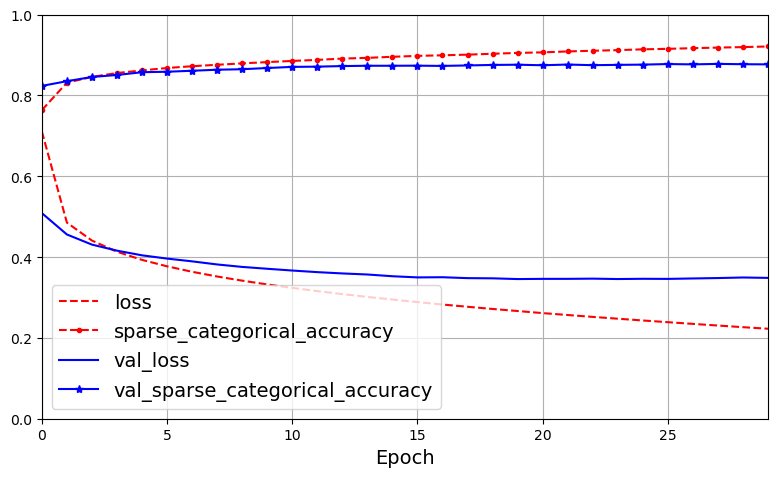

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot the learning curves for training and validation loss and accuracy
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
save_fig("keras_learning_curves_plot")  # extra code
plt.show()

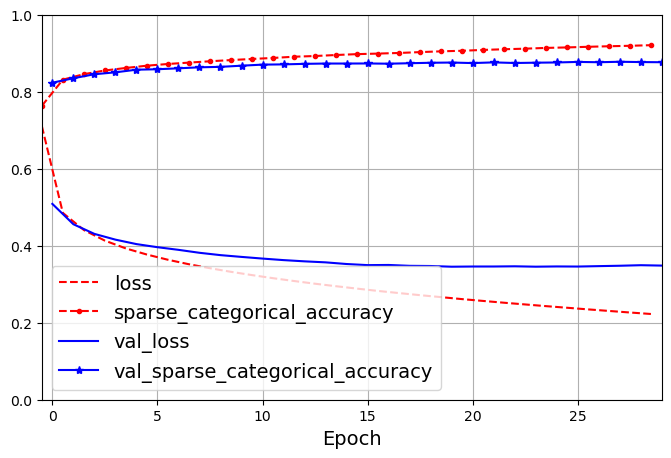

In [ ]:
# extra code – shows how to shift the training curve by -1/2 epoch
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()
plt.show()

`.evaluate()` is a Keras Model method that computes the loss and metrics on a given dataset. It takes input data (features and labels) and returns the loss value and metric values for the model on that data.

In [ ]:
model.evaluate(X_test, y_test) # evaluates the model on the test set

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3624 - sparse_categorical_accuracy: 0.8731


[0.3624149560928345, 0.8730999827384949]

---

### Using the model to make predictions

After training a Keras model, you can use it to make predictions on new data using the `model.predict()` method. This method takes input data and returns the model's output predictions.

In [ ]:
X_new = X_test[:3]
y_proba = model.predict(X_new) # predicts the probabilities 
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.31, 0.  , 0.02, 0.  , 0.67],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1], dtype=int64)

In [ ]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

Verify the predictions by comparing the predicted class IDs `y_pred` to the true labels `y_new`, inspect the predicted probabilities `y_proba` (e.g., `y_proba.round(2)`), and map predictions to class names with `class_names[y_pred]`. For example, print `y_proba.round(2)`, `y_pred`, `y_new`, and `class_names[y_pred]`.

In [ ]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

Then, call the corresponding lables from `y_test` to see the true classes for comparison.

In [ ]:
np.all(y_pred == y_new) # checks if predictions match true labels

True

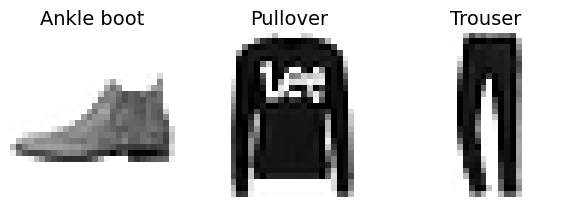

In [ ]:
# extra code – this cell generates and saves Figure 10–12
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]]) # true label
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

---

## Building a Regression MLP Using the Sequential API

This section shows how to build, train, and evaluate a regression MLP using Keras’ Sequential API on a tabular dataset (e.g., California Housing). Key steps:

- Prepare the data: split into training, validation, and test sets and scale features (StandardScaler or a tf.keras.layers.Normalization).
- Build a Sequential model with several Dense hidden layers (ReLU) and a single linear output neuron for continuous targets.
- Compile with an appropriate optimizer (e.g., SGD or Adam) and a regression loss (MSE or MAE); monitor RMSE (use the helper defined earlier).
- Train with validation_data and useful callbacks (EarlyStopping, ModelCheckpoint) to avoid overfitting.
- Evaluate on the test set and inspect diagnostics (RMSE, predicted vs actual scatter, residual histograms) to assess performance and guide hyperparameter tuning.

Keep experiments focused on architecture (depth/width), learning rate, regularization (dropout, weight decay), and input scaling—these typically have the largest impact on regression MLP performance.


### Loading the California Housing dataset

Let's load, split and scale the California housing dataset (the original one, not the modified one as in chapter 2):

In [ ]:
# extra code – load and split the California housing dataset, like earlier
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
print(housing.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [ ]:
# Split the data into training, validation, and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [ ]:
# extra code – shows the shapes of the datasets
housing.data.shape, X_train.shape, X_valid.shape, X_test.shape

((20640, 8), (11610, 8), (3870, 8), (5160, 8))

In [ ]:
from numpy import vstack
import numpy as np

# Convert feature names to a 2D array (as a header row)
header = np.array(housing['feature_names'])[np.newaxis, :]
# Stack the header and the first 5 rows of X_train
result = np.vstack([header, X_train[:5].astype(str)])
result

array([['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
        'AveOccup', 'Latitude', 'Longitude'],
       ['3.5214', '15.0', '3.0499445061043287', '1.106548279689234',
        '1447.0', '1.6059933407325193', '37.63', '-122.43'],
       ['5.3275', '5.0', '6.490059642147117', '0.9910536779324056',
        '3464.0', '3.4433399602385686', '33.69', '-117.39'],
       ['3.1', '29.0', '7.5423728813559325', '1.5915254237288134',
        '1328.0', '2.2508474576271187', '38.44', '-122.98'],
       ['7.1736', '12.0', '6.289002557544757', '0.9974424552429667',
        '1054.0', '2.6956521739130435', '33.55', '-117.7'],
       ['2.0549', '13.0', '5.312457454050374', '1.0850918992511913',
        '3297.0', '2.2443839346494214', '33.93', '-116.93']], dtype='<U32')

The following code builds, compiles, and trains a Keras Sequential MLP for California housing regression. It normalizes the inputs, defines several ReLU-activated hidden layers with a single linear output, compiles the model with MSE loss (tracking RMSE), uses validation data and callbacks (EarlyStopping and ModelCheckpoint), and finally evaluates the model on the test set.


In [ ]:
tf.random.set_seed(42)

# Define the normalization layer
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

# Build the model
model = tf.keras.Sequential([
    norm_layer, # Normalize inputs
    tf.keras.layers.Dense(50, activation="relu"), # First hidden layer
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1) # Output layer for regression
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3) # Adam optimizer

# Compile the model
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# Adapt the normalization layer to the training data
norm_layer.adapt(X_train)

# fit the model with validation data
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

# evaluate the model on the test set
mse_test, rmse_test = model.evaluate(X_test, y_test)

# make predictions on new data
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20


c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.9101 - loss: 0.8283 - val_RootMeanSquaredError: 0.6509 - val_loss: 0.4236
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6177 - loss: 0.3815 - val_RootMeanSquaredError: 0.6299 - val_loss: 0.3968
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5919 - loss: 0.3503 - val_RootMeanSquaredError: 0.6024 - val_loss: 0.3629
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5799 - loss: 0.3363 - val_RootMeanSquaredError: 0.9132 - val_loss: 0.8340
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5702 - loss: 0.3252 - val_RootMeanSquaredError: 1.2586 - val_loss: 1.5840
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5714 - loss: 0.3265 - val_RootMeanSquaredError: 1.3106 - val_loss: 1.7177
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5584 - loss: 0.3118 -


**optimizer = tf.keras.optimizer.Adam(learning_rate=1e-3)**

This line creates an instance of the Adam optimizer with a learning rate of 0.001:

- It implements the Adam algorithm (adaptive estimates of first and second moments of gradients, controlled by defaults like beta1=0.9 and beta2=0.999), which makes it a robust, widely used default for many tasks.
- As an object, it’s stateful (it stores moment estimates per trainable variable) and is typically passed to `model.compile(optimizer=optimizer, ...)` or used directly in custom training loops.
- The learning rate (here 1e-3) is the main hyperparameter to tune; it can be replaced with a schedule or adjusted during training.

If a learning-rate schedule is desired, pass a schedule object instead of a scalar, for example:

```python
optimizer = tf.keras.optimizers.Adam(
    learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(1e-3, decay_steps=10000, decay_rate=0.5)
)
```


Gotchas: try AdamW for correct weight decay, consider switching to SGD+momentum for better generalization on some problems, and remember to tune the learning rate (and possibly clip gradients or use warmup) depending on batch size and dataset.

The Adam optimizer maintains exponential moving averages of both the gradients (first moment) and the squared gradients (second moment) to compute adaptive learning rates for each parameter. The hyperparameters $\beta_1=0.9$ and $\beta_2=0.999$ control how quickly these moving averages decay: $\beta_1$ gives a short memory (about 10 steps), while $\beta_2$ gives a much longer memory (about 1000 steps). These defaults are effective for most problems, making Adam a popular and robust choice.

At each step $t$, given gradient $g_t$, Adam updates as follows:
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t,\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2,
$$
with bias correction:
$$
\hat m_t = \frac{m_t}{1-\beta_1^t},\qquad
\hat v_t = \frac{v_t}{1-\beta_2^t},
$$
and parameter update:
$$
\theta_{t+1} = \theta_t - \alpha\, \frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}.
$$
The small $\varepsilon$ (typically $10^{-7}$ or $10^{-8}$) prevents division by zero.

In practice, you usually keep $\beta_1$ and $\beta_2$ at their default values and tune the learning rate $\alpha$ (and sometimes $\varepsilon$). For improved regularization, consider AdamW (decoupled weight decay). AMSGrad is another Adam variant with stronger theoretical guarantees. While Adam is fast and reliable for initial training, switching to SGD with momentum for final fine-tuning can sometimes improve generalization.


In [ ]:
rmse_test

0.5378540754318237

In [ ]:
y_pred, y_test[:3]

(array([[0.46170986],
        [1.117087  ],
        [5.1573358 ]], dtype=float32),
 array([0.477  , 0.458  , 5.00001]))

---
## Building Complex Models Using the Functional API

Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see [paper](https://ai.google/research/pubs/pub45413)) connects all or part of the inputs directly to the output layer.

### Wide & Deep Regression Model with Keras Functional API

This code demonstrates how to build a **Wide & Deep regression model** using the Keras Functional API. The model combines **a normalized "wide" input path (raw features)** with **a "deep" path (two Dense layers with ReLU activation)**, then concatenates both representations before a final linear output for regression. This architecture enables the model to learn both simple and complex feature interactions, making it suitable for tabular regression tasks such as predicting house prices. The normalization layer is adapted to the training data to standardize inputs, and the model is constructed by explicitly connecting layers and inputs using the Functional API.

In [ ]:
# extra code – reset the name counters and make the code reproducible
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:
# Normalization layer (feature-wise standardization).
# Call normalization_layer.adapt(X_train) before training so it learns mean/std.
normalization_layer = tf.keras.layers.Normalization()

# Two Dense hidden layers (deep path) with ReLU activations
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")

# Concatenate layer to implement a "wide & deep" style connection:
# it will join the normalized raw inputs ("wide" part) with the deep features
concat_layer = tf.keras.layers.Concatenate()

# Linear output for regression (single continuous target)
output_layer = tf.keras.layers.Dense(1)

# Functional API input: shape matches training features (e.g., tabular data)
input_ = tf.keras.layers.Input(shape=X_train.shape[1:])

# Apply normalization to inputs
normalized = normalization_layer(input_)

# Deep path: two successive hidden layers
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)

# Concatenate normalized inputs with deep representation:
# resulting shape = (batch_size, n_input_features + 30)
concat = concat_layer([normalized, hidden2])

# Final prediction
output = output_layer(concat)

# Build the Model that maps inputs to outputs
model = tf.keras.Model(inputs=[input_], outputs=[output])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,256 (4.91 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 17 (72.00 B)

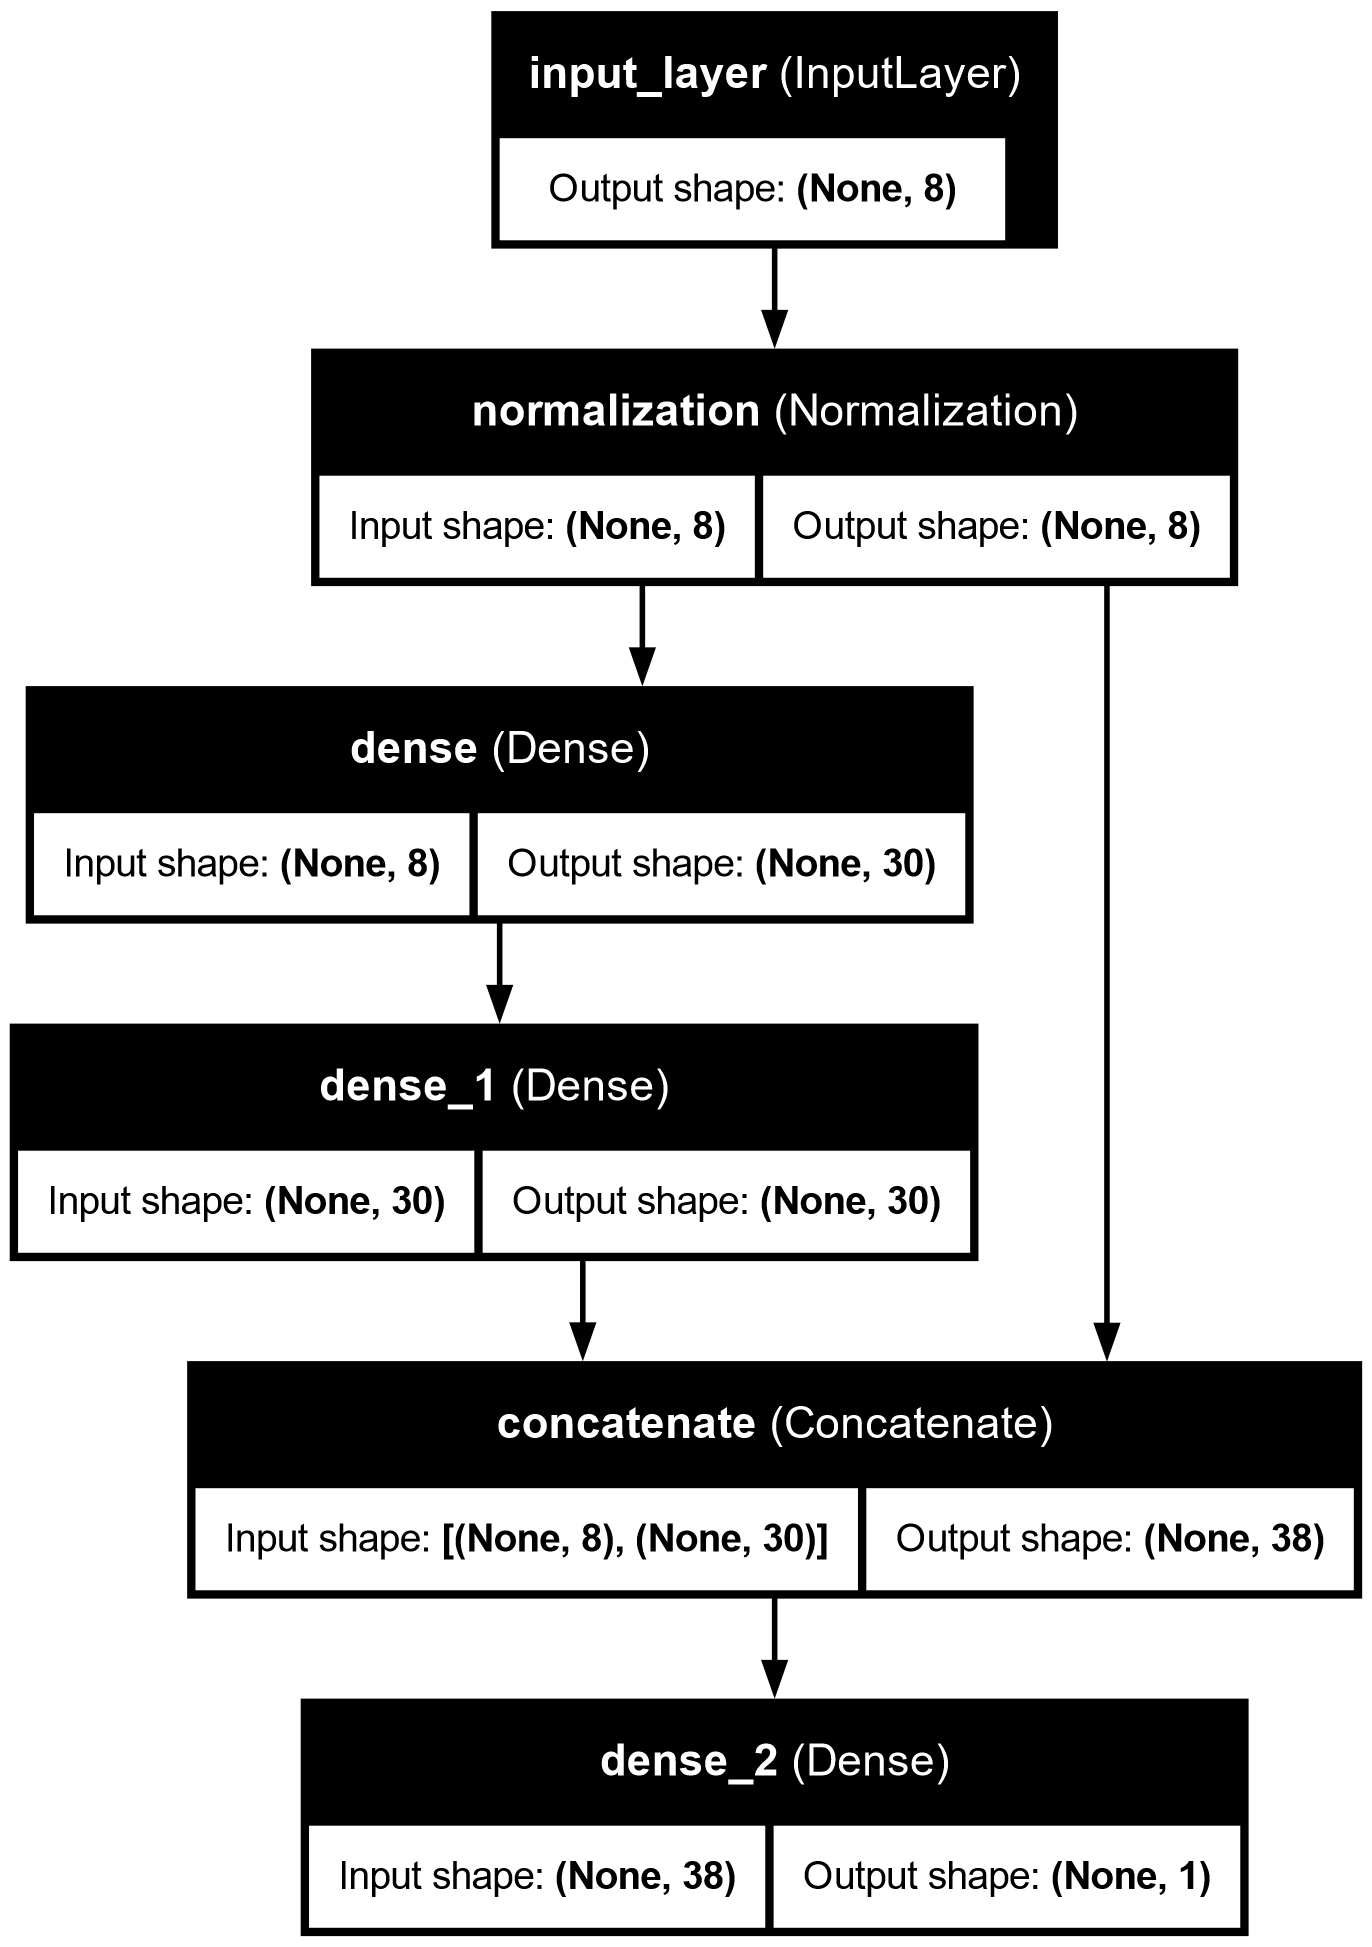

In [ ]:
tf.keras.utils.plot_model(model, to_file="my_california_housing_model.png", show_shapes=True, show_layer_names=True)

In [ ]:
# Create an Adam optimizer with a small learning rate (good default for many problems)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compile the model for regression: MSE loss and track RMSE as a metric
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# Fit the normalization layer so it learns the training data mean and variance
normalization_layer.adapt(X_train)

# Train the model and validate on the validation set each epoch;
# History will contain training/validation loss and metrics per epoch
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

# Evaluate the model on the test set.
# model.evaluate returns [loss, metric1, metric2, ...] (here: MSE and RMSE)
mse_test = model.evaluate(X_test, y_test)
mse_test

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 1.0934 - loss: 1.1956 - val_RootMeanSquaredError: 0.8913 - val_loss: 0.7944
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6842 - loss: 0.4682 - val_RootMeanSquaredError: 1.3789 - val_loss: 1.9013
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6345 - loss: 0.4026 - val_RootMeanSquaredError: 1.3345 - val_loss: 1.7809
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6269 - loss: 0.3930 - val_RootMeanSquaredError: 1.6975 - val_loss: 2.8814
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6105 - loss: 0.3727 - val_RootMeanSquaredError: 1.6451 - val_loss: 2.7064
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6110 - loss: 0.3733 - val_RootMeanSquaredError: 1.6143 - val_loss: 2.6060
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5969 - los

[0.31193962693214417, 0.5585155487060547]

In [ ]:

# Predict targets for new inputs (e.g., X_new = X_test[:3]); y_pred contains predicted values
y_pred = model.predict(X_new)
y_pred, y_test[:3]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


(array([[0.6508799],
        [1.326822 ],
        [4.4779067]], dtype=float32),
 array([0.477  , 0.458  , 5.00001]))

---

### Wide & Deep Regression Model with Multiple Inputs Using Keras Functional API

What if you want to send *different subsets of input features* through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [ ]:
tf.random.set_seed(42)  # extra code

This code builds a **Wide & Deep regression model with multiple inputs** using the Keras Functional API. The model processes two different subsets of features: a "wide" path (features 0–4) and a "deep" path (features 2–7). Each path has its own normalization layer, and the deep path includes two Dense layers with ReLU activation. The outputs of both paths are concatenated and passed to a final Dense layer for regression. This architecture enables the model to learn both simple and complex feature interactions from different feature sets, making it well-suited for tabular regression tasks such as predicting house prices. The normalization layers are adapted to their respective training data subsets to ensure proper input scaling.

In [ ]:
# Define two input layers: one for the "wide" path (features 0 to 4), one for the "deep" path (features 2 to 7)
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7

# Add normalization layers for each input branch
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

# Deep path: two dense hidden layers with ReLU activation
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)

# Concatenate the normalized wide input and the output of the deep path
concat = tf.keras.layers.concatenate([norm_wide, hidden2])

# Output layer: single neuron for regression
output = tf.keras.layers.Dense(1)(concat)

# Build the model with two inputs and one output
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

These two lines define two Keras input tensors for a Functional API model:

- `input_wide = tf.keras.layers.Input(shape=[5])`  
    Expects each sample to be a vector of length 5 (shape: $(m, 5)$ for a batch of $m$ samples).

- `input_deep = tf.keras.layers.Input(shape=[6])`  
    Expects each sample to be a vector of length 6 (shape: $(m, 6)$ for a batch).

In this context, these correspond to different feature subsets: features 0–4 for the wide path and features 2–7 for the deep path (with features 2–4 included in both). The `Input` objects are symbolic tensors used to build models with the Functional API.

**Tips:**
- Ensure your input arrays match the expected shapes, e.g., `X_train_wide.shape == (n_samples, 5)` and `X_train_deep.shape == (n_samples, 6)`.
- Pass data as a tuple `(X_train_wide, X_train_deep)` to `model.fit()`.
- You can specify `dtype`, `name`, or use `None` for flexible shapes if needed.

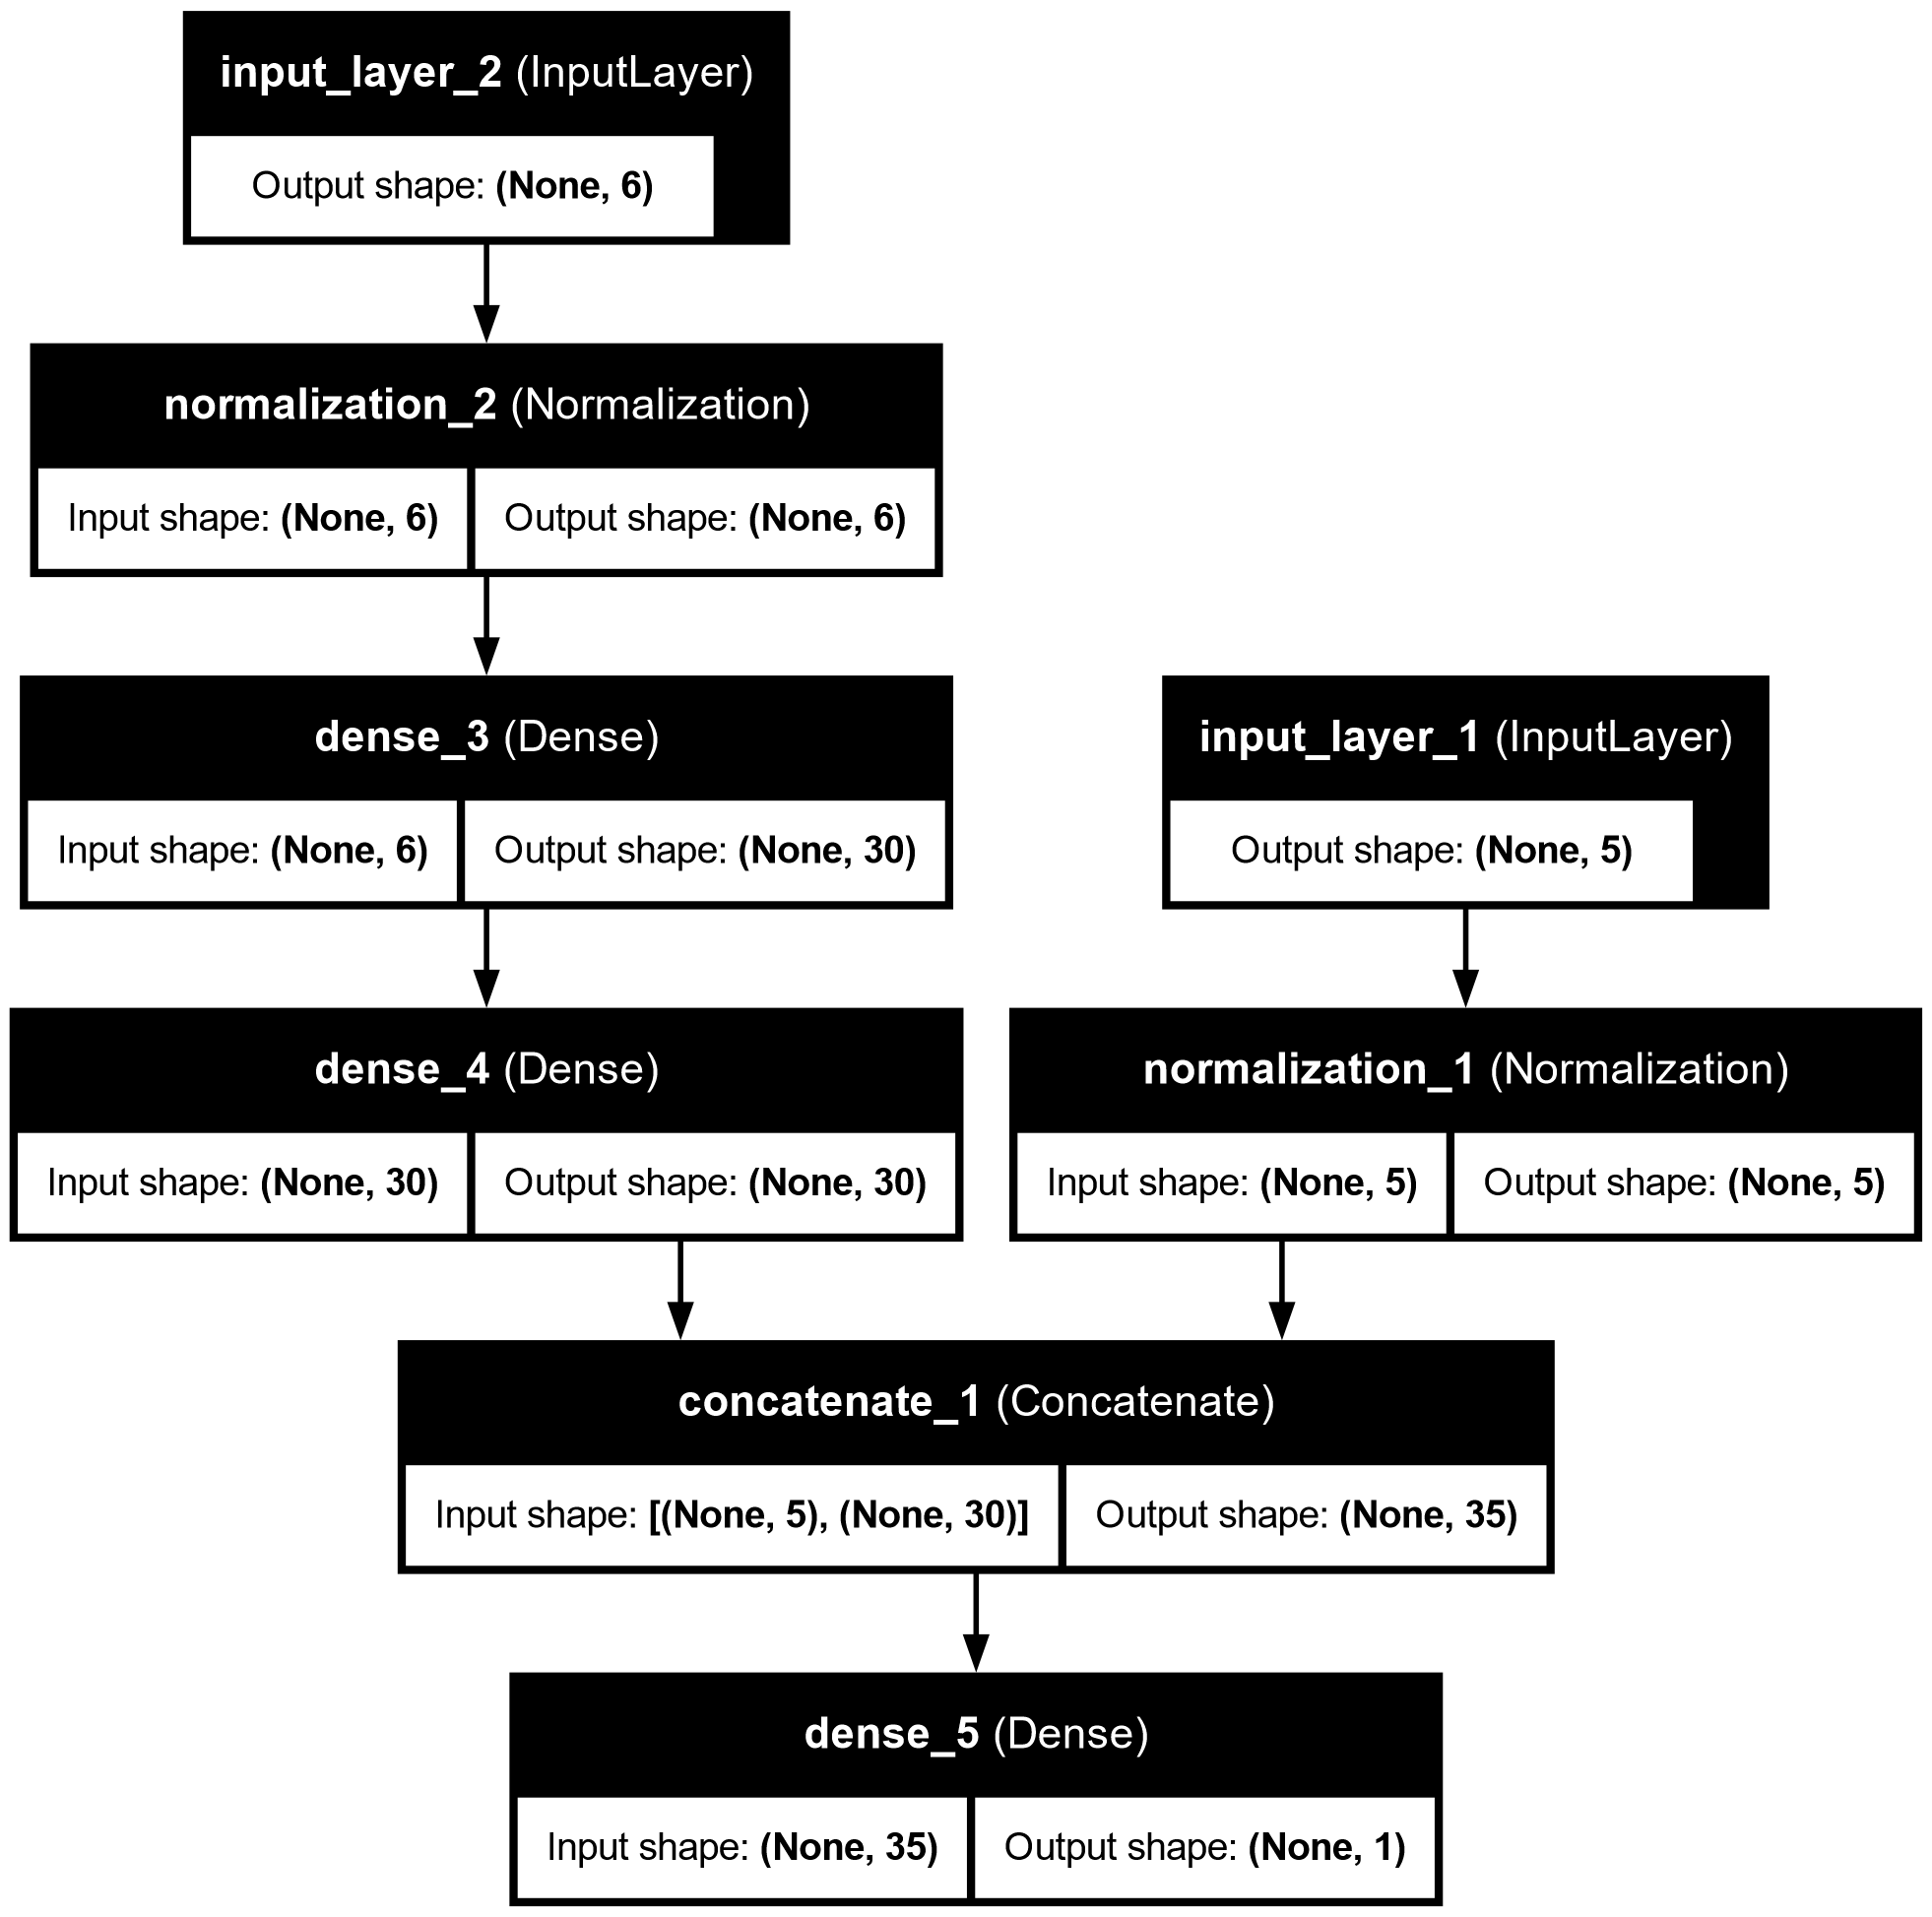

In [ ]:
# Visualize the model
tf.keras.utils.plot_model(model, to_file="my_wide_and_deep_model.png", show_shapes=True, show_layer_names=True)

In [ ]:
# Create Adam optimizer with learning rate 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compile the model for regression with MSE loss and RMSE metric
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# Split the input features for the wide and deep paths
X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

# Adapt normalization layers to the corresponding training data
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

# Train the model using the wide and deep inputs, with validation data
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))

# Evaluate the model on the test set
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
mse_test

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 1.3170 - loss: 1.7345 - val_RootMeanSquaredError: 0.8182 - val_loss: 0.6694
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.7361 - loss: 0.5418 - val_RootMeanSquaredError: 1.0587 - val_loss: 1.1209
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6721 - loss: 0.4517 - val_RootMeanSquaredError: 0.9323 - val_loss: 0.8691
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6431 - loss: 0.4136 - val_RootMeanSquaredError: 1.1715 - val_loss: 1.3725
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6342 - loss: 0.4022 - val_RootMeanSquaredError: 1.2619 - val_loss: 1.5925
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6221 - loss: 0.3869 - val_RootMeanSquaredError: 1.1774 - val_loss: 1.3863
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6155 - los

[0.33581599593162537, 0.5794963240623474]

In [ ]:

# Make predictions on new data samples
y_pred = model.predict((X_new_wide, X_new_deep))
y_pred, y_test[:3]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


(array([[0.453382 ],
        [1.2499837],
        [3.6170363]], dtype=float32),
 array([0.477  , 0.458  , 5.00001]))

This creates an Adam optimizer with learning rate 1e-3 and compiles the Keras model to minimize mean squared error (MSE) while reporting RootMeanSquaredError as a metric — so training will track both the loss and the RMSE.

The next lines slice the full feature matrices into the two inputs expected by the wide & deep model: the wide input takes columns 0–4 and the deep input takes columns 2 onward. For a batch of size $m$ these arrays have shapes $ (m, 5) $ and $ (m, 6) $ respectively. A small prediction set of the first three test rows is extracted as X_new_wide/X_new_deep.

Calling `norm_layer_wide.adapt(...)` and `norm_layer_deep.adapt(...)` computes per-feature mean and variance for each input subset and stores that state in the Normalization layers so they will normalize inputs consistently during training and inference.

Finally, `model.fit(...)` trains the model using a tuple of inputs ((X_train_wide, X_train_deep), y_train) and nested validation data, `model.evaluate(...)` runs the evaluation on the test inputs (it returns [loss, metric] for this setup — consider unpacking like `mse_test, rmse_test = model.evaluate(...)` or using `return_dict=True`), and `model.predict(...)` returns the prediction array(s) for the small X_new pair.

Gotchas/tips: ensure the input arrays have the exact shapes and dtypes the model expects, be aware that duplicating features in both paths increases model capacity (and overfitting risk), and if you adapt a Normalization layer again after it’s been used in a compiled model you may need to recompile or verify behavior.

---

### Auxiliary Output for Regularization
Adding an auxiliary output for regularization:

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

This sub-section demonstrates how to compile a Keras model with two outputs, each having its own loss function and evaluation metric. The model uses mean squared error (MSE) as the loss for both outputs and applies different loss weights to prioritize the main output. To avoid naming conflicts when using the same metric type for multiple outputs, each metric is given a unique name. This setup is useful for multi-output regression tasks, such as when a model predicts both a primary and an auxiliary target.

In [ ]:
# Define two input layers for the wide and deep paths
input_wide = tf.keras.layers.Input(shape=[5])  # Input for features 0 to 4 (wide path)
input_deep = tf.keras.layers.Input(shape=[6])  # Input for features 2 to 7 (deep path)

# Add normalization layers for each input branch
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)   # Normalize wide input
norm_deep = norm_layer_deep(input_deep)   # Normalize deep input

# Deep path: two dense hidden layers with ReLU activation
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)

# Concatenate the normalized wide input and the output of the deep path
concat = tf.keras.layers.concatenate([norm_wide, hidden2])

# Main output: single neuron for regression (final prediction)
output = tf.keras.layers.Dense(1)(concat)

# Auxiliary output: single neuron for regression (from deep path, for regularization)
aux_output = tf.keras.layers.Dense(1)(hidden2)

# Build the model with two inputs and two outputs (main and auxiliary)
model = tf.keras.Model(inputs=[input_wide, input_deep],
                       outputs=[output, aux_output])

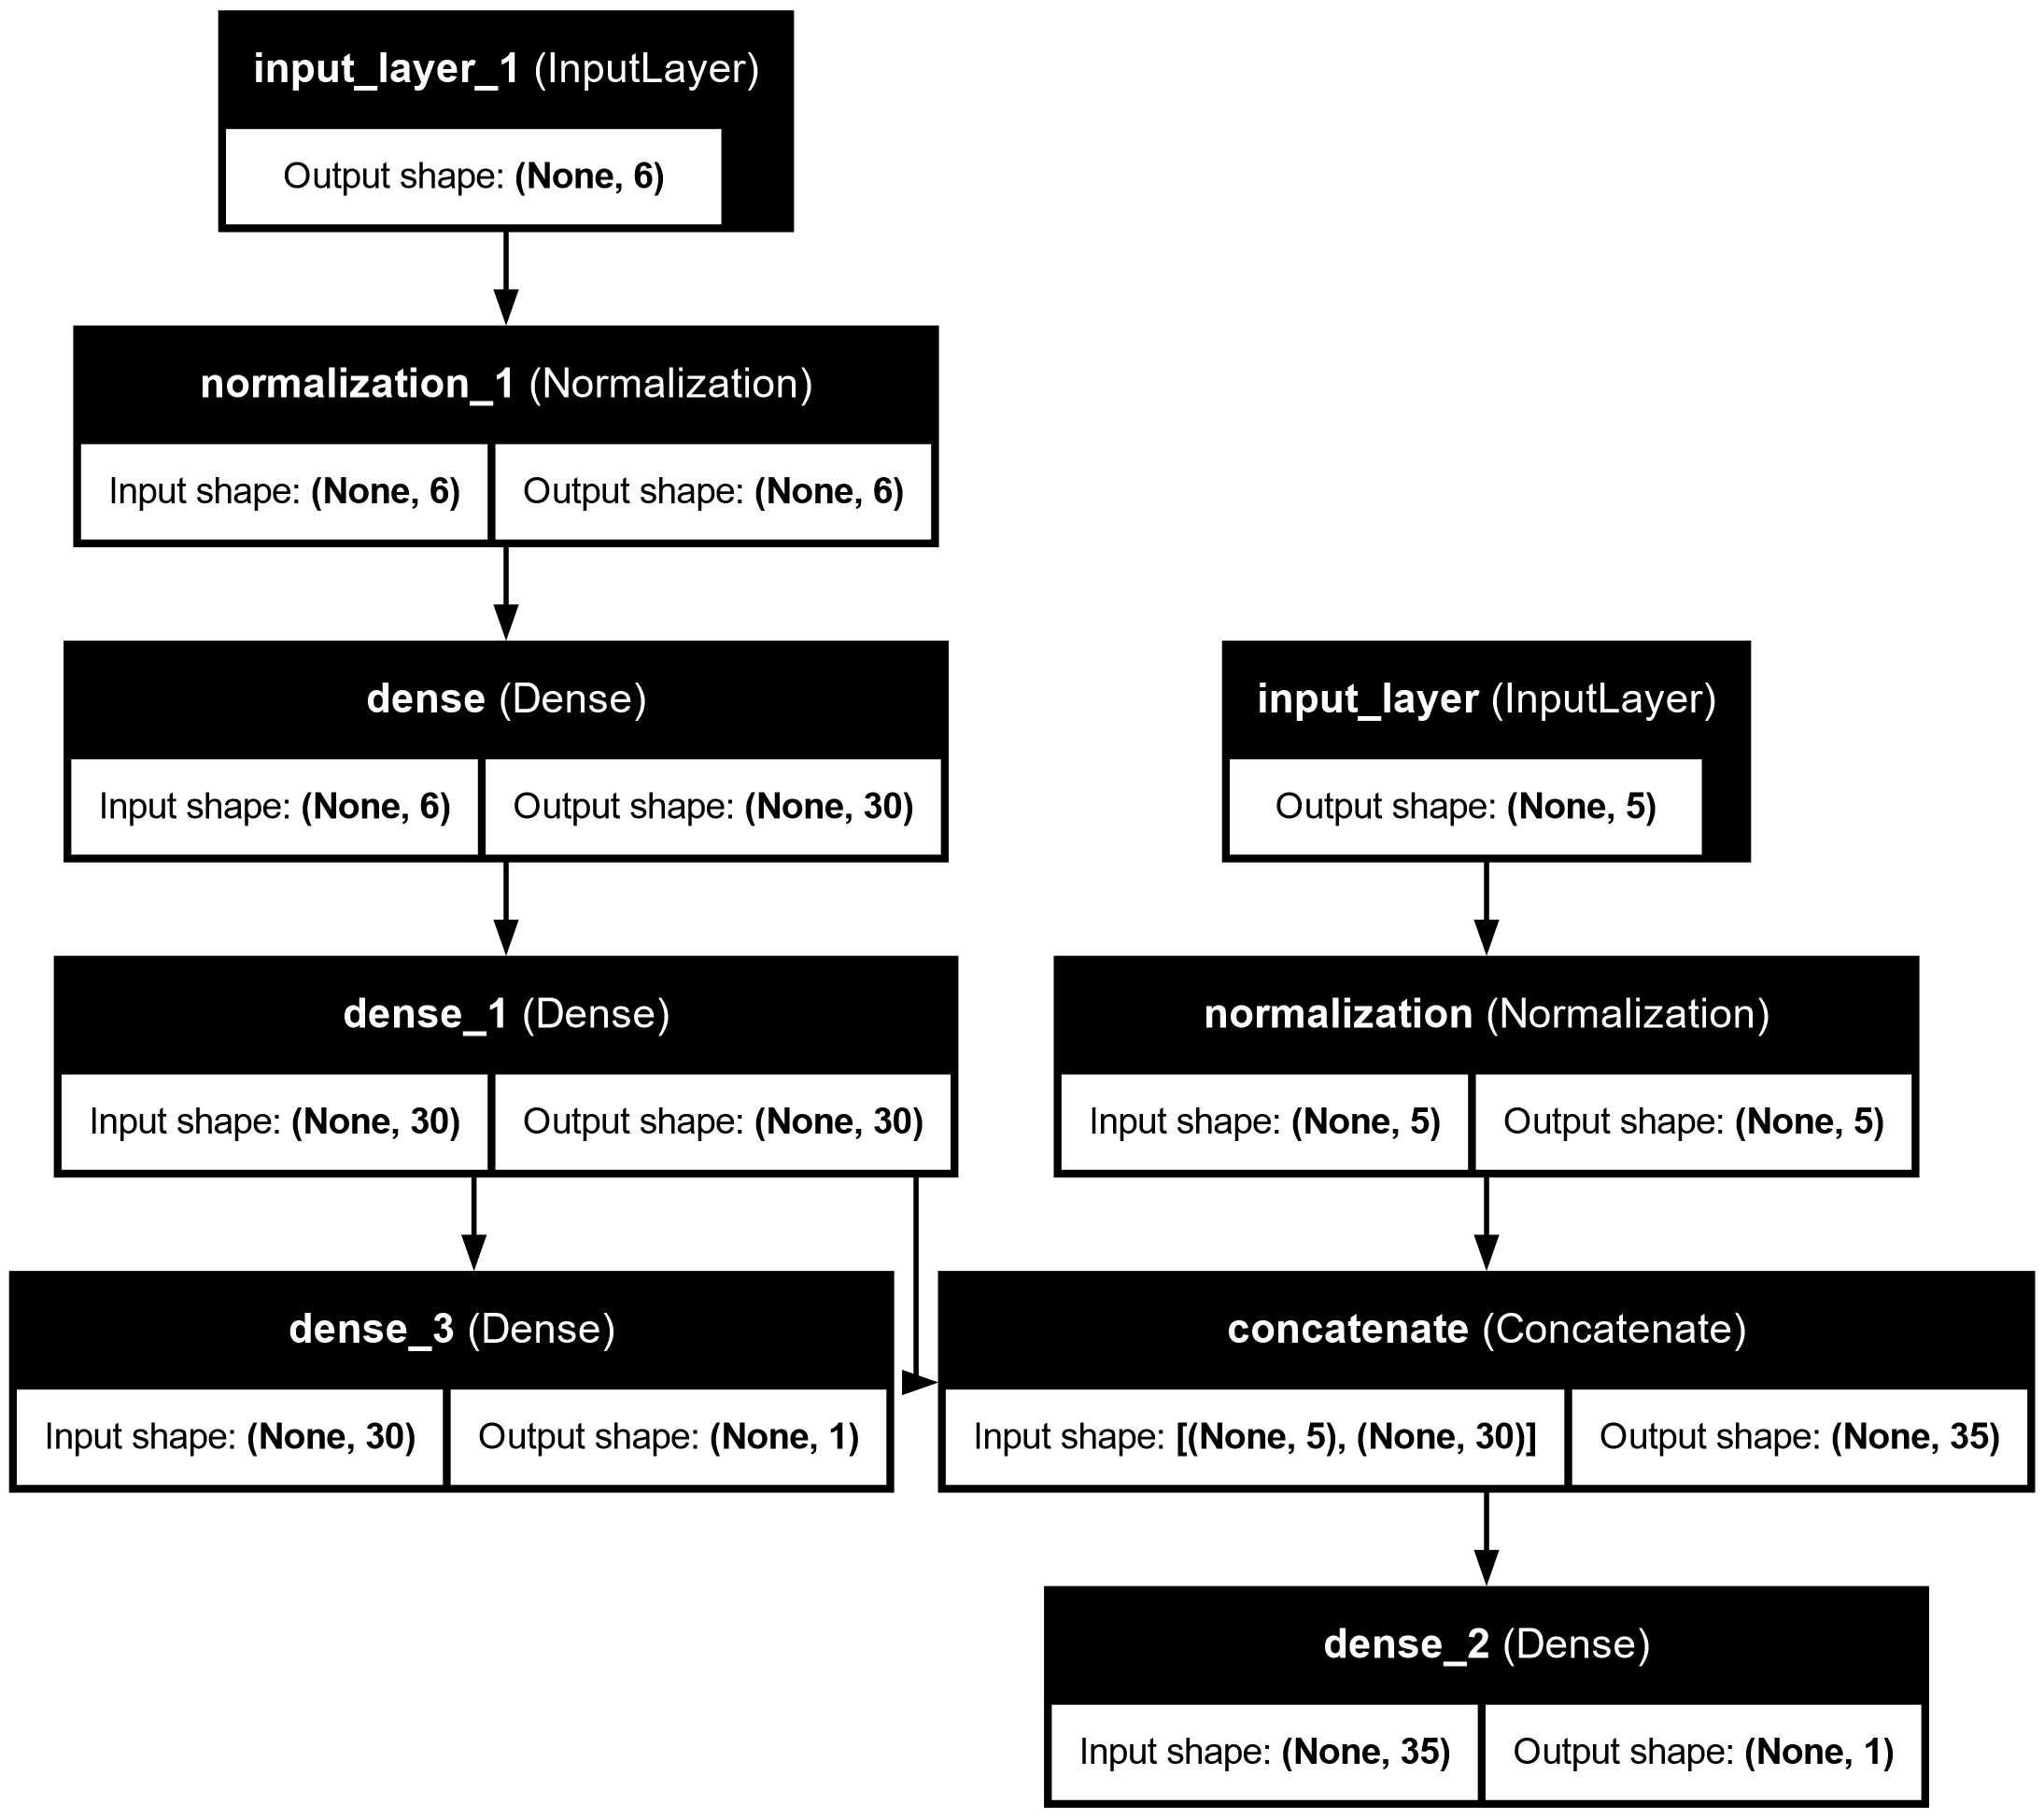

In [ ]:
tf.keras.utils.plot_model(model, to_file="my_wide_and_deep_with_aux_output_model.png", show_shapes=True, show_layer_names=True)

**Warning**: For models with multiple outputs, Keras expects one metric per output. For example, for a model with two outputs you can either pass a list with one metric per output:

`metrics=["RootMeanSquaredError", "RootMeanSquaredError"]`

or pass a dict mapping output names to metrics:

`metrics={"output":"RootMeanSquaredError", "aux_output":"RootMeanSquaredError"}`

Likewise supply one loss per output (e.g., `loss=["mse","mse"]` or `loss={"output":"mse","aux_output":"mse"}`) and optionally use `loss_weights` to weight the losses.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compile the model with two losses and weighted loss contributions
model.compile(
    loss=("mse", "mse"),
    loss_weights=(0.9, 0.1),
    optimizer=optimizer,
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse_main"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse_aux")
    ]
)

**What this does (concise):**

- `optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)`  
    Creates the Adam optimizer and assigns it to the `optimizer` variable.

- `loss = ("mse", "mse")`  
    Two losses are provided (one per output): mean squared error for the main and auxiliary outputs.

- `loss_weights = (0.9, 0.1)`  
    The total loss minimized is `0.9 * loss_main + 0.1 * loss_aux`. The auxiliary output is downweighted so it regularizes the model without dominating training.

- `metrics = [tf.keras.metrics.RootMeanSquaredError(name="rmse_main"), tf.keras.metrics.RootMeanSquaredError(name="rmse_aux")]`  
    Keras expects one metric per output for multi-output models, so two RMSE metric objects are provided and are named for clearer logging (`rmse_main`, `rmse_aux`).

Notes: the History will record the total loss plus each output’s loss and metric. For clarity you can also pass dicts keyed by output names for losses, weights, and metrics.

In [ ]:
# Adapt the normalization layers to the training subsets so they learn per-feature
# mean and variance (used to normalize inputs during training and inference).
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

# Fit the model:
# - Inputs: a tuple (X_train_wide, X_train_deep) matching the two model inputs.
# - Targets: a tuple (y_train, y_train) because the model has two outputs
#   (main and auxiliary). Here we use the same ground-truth values for both outputs.
# - validation_data uses the same structure for validation inputs and targets.
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train),
    epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - dense_2_loss: 1.5346 - dense_2_rmse_main: 1.2390 - dense_3_loss: 2.2288 - dense_3_rmse_aux: 1.4931 - loss: 1.6045 - val_dense_2_loss: 2.4606 - val_dense_2_rmse_main: 1.5690 - val_dense_3_loss: 10.2871 - val_dense_3_rmse_aux: 3.2081 - val_loss: 3.2448
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_2_loss: 0.5003 - dense_2_rmse_main: 0.7073 - dense_3_loss: 0.8520 - dense_3_rmse_aux: 0.9231 - loss: 0.5355 - val_dense_2_loss: 0.6434 - val_dense_2_rmse_main: 0.8023 - val_dense_3_loss: 5.3981 - val_dense_3_rmse_aux: 2.3239 - val_loss: 1.1193
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_2_loss: 0.4315 - dense_2_rmse_main: 0.6568 - dense_3_loss: 0.6488 - dense_3_rmse_aux: 0.8055 - loss: 0.4532 - val_dense_2_loss: 0.4031 - val_dense_2_rmse_main: 0.6349 - val_dense_3_loss: 2.6265 - val_dense_3_rmse_aux: 1.6210 - val_loss: 0.6256
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - dense_2_loss: 0.4061 - dense_2_rm

**Warning**: in recent TF version, `evaluate()` also returns the main metric and the aux metric. To ensure the code works in both old and new versions, we only look at the first 3 elements of `eval_results` (i.e., just the losses):

In [ ]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_2_loss: 0.3349 - dense_2_rmse_main: 0.5789 - dense_3_loss: 0.4053 - dense_3_rmse_aux: 0.6364 - loss: 0.3422  


In [ ]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [ ]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model.output_names, y_pred_tuple))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


---

## Using the Subclassing API to Build Dynamic Models

In some cases, you may want to build models that are more dynamic and flexible than what the Sequential or Functional APIs allow. The Subclassing API lets you *define custom models by subclassing `tf.keras.Model` and implementing the `call()` method*. This approach is useful for models with complex architectures, dynamic behavior, or custom training loops.

In [ ]:

class WideAndDeepModel(tf.keras.Model):
    """Wide & Deep regression model built with Keras Model subclass.

    This model accepts two inputs (wide and deep), normalizes each branch,
    passes the deep branch through two Dense(hidden) layers, concatenates the
    normalized wide input with the deep features, and produces a main and an
    auxiliary scalar output. The auxiliary output can be used as a regularizer.

    Args:
        units (int): Number of units in each hidden Dense layer (deep path).
        activation (str or callable): Activation for the hidden layers.
        **kwargs: Additional keyword arguments forwarded to tf.keras.Model.

    Attributes:
        norm_layer_wide (Normalization): Normalization layer for the wide input.
        norm_layer_deep (Normalization): Normalization layer for the deep input.
        hidden1, hidden2 (Dense): Dense layers for the deep path.
        concat (Concatenate): Layer that concatenates wide and deep features.
        main_output, aux_output (Dense): Output layers for main and auxiliary predictions.
        output_names (list[str]): Names of the outputs.

    Call signature:
        inputs: tuple(input_wide, input_deep) where each is a Tensor.
        training (bool | None): Passed to normalization layers to control behavior.
        mask: Unused.

    Returns:
        Tuple[Tensor, Tensor]: (main_output, aux_output)
    """
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # support naming and other Model kwargs
        # Preprocessing layers for each branch
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        # Hidden layers for the deep path
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.concat = tf.keras.layers.Concatenate()
        # Output layers: main output (uses concatenated features) and auxiliary output (deep path)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)
        self.output_names = ["main_output", "aux_output"]

    def call(self, inputs: tuple[tf.Tensor, tf.Tensor], training: bool | None = None, mask=None):
        """Runs the model on a batch of inputs.

        Args:
            inputs: Tuple[input_wide, input_deep], where each is a Tensor for the
                corresponding branch.
            training: Optional bool. If True, run in training mode (affects normalization layers).
            mask: Unused.

        Returns:
            Tuple[Tensor, Tensor]: (main_output, aux_output), each with shape (batch_size, 1).
        """
        input_wide, input_deep = inputs

        # Normalize each input branch (uses the state set by .adapt() on the Normalization layers)
        norm_wide = self.norm_layer_wide(input_wide, training=training)
        norm_deep = self.norm_layer_deep(input_deep, training=training)

        # Deep path: apply dense layers
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)

        # Combine the wide and deep representations and produce outputs
        concat = self.concat([norm_wide, hidden2])
        output = self.main_output(concat)     # main prediction from both paths
        aux_output = self.aux_output(hidden2) # auxiliary prediction from deep path

        return output, aux_output

### Explanation of call()

- Signature: `def call(self, inputs: tuple[tf.Tensor, tf.Tensor], training: bool | None = None, mask=None)`  
    - `inputs` is expected to be a tuple `(input_wide, input_deep)` (or a list); `training` is a boolean (or None) forwarded to layers that behave differently in training vs inference (e.g., Normalization/BatchNorm/Dropout); `mask` is unused here but accepted for API compatibility.

- What it does (step‑by‑step):
    1. Unpacks inputs: `input_wide, input_deep = inputs`.
    2. Normalizes each branch:
                - `norm_wide = self.norm_layer_wide(input_wide, training=training)`
                - `norm_deep = self.norm_layer_deep(input_deep, training=training)`
    3. Processes the deep path through the dense layers:
                - `hidden1 = self.hidden1(norm_deep)`
                - `hidden2 = self.hidden2(hidden1)`  — shape `(batch_size, units)`.
    4. Concatenates the wide representation and deep features:
                - `concat = self.concat([norm_wide, hidden2])` → shape `(batch_size, n_wide + units)`.
    5. Produces outputs:
                - `output = self.main_output(concat)` (main prediction)
                - `aux_output = self.aux_output(hidden2)` (auxiliary prediction)

- Return value:
    - Returns a tuple `(output, aux_output)`, each with shape `(batch_size, 1)`.

- Notes / usage:
    - Keras calls `call()` during `fit`, `evaluate`, and `predict`. The `training` flag is important if you add layers that depend on it (pass `None` to let layers decide).
    - `mask` is accepted for API compatibility but unused in this implementation.
    - Because it returns two outputs, `compile()` / `fit()` must supply two losses/metrics and targets (or use dicts / duplicate the target as shown earlier).
    - Example calls:
        - `main_out, aux_out = model((X_wide, X_deep), training=False)`
        - `y_pred_tuple = model.predict((X_new_wide, X_new_deep))` (returns a tuple/list)
        - To map outputs to names: `y_pred = dict(zip(model.output_names, y_pred_tuple))`

In [ ]:

tf.random.set_seed(42)  # extra code – just for reproducibility
model = WideAndDeepModel(30, activation="relu", name="my_cool_model") # create the model instance

**Warning**: for multi‑output models Keras requires one loss per output and one metric (or list of metrics) per output. In practice you can:

- Pass lists/tuples in the same order as the model outputs, e.g.
    - `loss=("mse","mse")`
    - `loss_weights=(0.9, 0.1)`
    - `metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse_main"), tf.keras.metrics.RootMeanSquaredError(name="rmse_aux")]`

- Or pass dicts keyed by output names, which is clearer and order‑independent, e.g.
    - `loss={"output":"mse","aux_output":"mse"}`
    - `metrics={"output":[tf.keras.metrics.RootMeanSquaredError(name="rmse_main")], "aux_output":[tf.keras.metrics.RootMeanSquaredError(name="rmse_aux")]}`

So in the example below I replaced `loss="mse"` with `loss=["mse","mse"]`, and `metrics=["RootMeanSquaredError"]` with `metrics=["RootMeanSquaredError","RootMeanSquaredError"]`. Prefer using named metric objects (with `name=...`) or dicts for clarity; the History will record the total loss plus each output’s loss and metric values.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=optimizer,
              metrics={output: "RootMeanSquaredError" for output in model.output_names})

model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)

history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))

eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - aux_output_RootMeanSquaredError: 1.4332 - aux_output_loss: 2.0534 - loss: 2.0229 - main_output_RootMeanSquaredError: 1.4211 - main_output_loss: 2.0188 - val_aux_output_RootMeanSquaredError: 1.9428 - val_aux_output_loss: 3.7728 - val_loss: 1.2412 - val_main_output_RootMeanSquaredError: 0.9796 - val_main_output_loss: 0.9594
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_RootMeanSquaredError: 0.8460 - aux_output_loss: 0.7157 - loss: 0.6364 - main_output_RootMeanSquaredError: 0.7922 - main_output_loss: 0.6276 - val_aux_output_RootMeanSquaredError: 1.2951 - val_aux_output_loss: 1.6766 - val_loss: 0.6791 - val_main_output_RootMeanSquaredError: 0.7538 - val_main_output_loss: 0.5680
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_RootMeanSquaredError: 0.7687 - aux_output_loss: 0.5909 - loss: 0.5296 - main_output_RootMeanSquaredError: 0.7230 - main_output_loss: 0.5228 - val_aux_output_RootMeanSquaredError: 

This creates an Adam optimizer with learning rate 1e-3 and compiles the Keras model for a two‑output regression problem. Each output uses mean squared error (`"mse"`) and the losses are combined with weights `[0.9, 0.1]`, so the total loss minimized is the weighted sum $L = 0.9\,L_{\text{main}} + 0.1\,L_{\text{aux}}$. Because the model has two outputs, the code also supplies one metric per output (`"RootMeanSquaredError"` for each).

The two normalization layers are adapted to their respective training subsets so they compute and store per‑feature statistics used at train/inference time: `norm_layer_wide.adapt(X_train_wide)` and `norm_layer_deep.adapt(X_train_deep)`.

Training uses a tuple of inputs and a tuple of targets: `model.fit((X_train_wide, X_train_deep), (y_train, y_train), ...)`, and validation data follows the same structure. `model.evaluate(...)` returns a list of values in a stable order (total loss, per‑output losses, then per‑output metrics), so unpack accordingly or use `return_dict=True`. `model.predict(...)` returns a tuple of predictions (main, auxiliary) that the code unpacks into `y_pred_main, y_pred_aux`.

Gotchas: ensure each input array has the exact shape/dtype the corresponding `Input` expects (e.g., `(n,5)` and `(n,6)`), be aware that sharing features across both branches increases model capacity (and overfitting risk), and Keras requires one metric per output for multi‑output models.

---

## Saving and Restoring a Model

Keras provides several ways to save and restore models, including saving the entire model architecture, weights, and optimizer state in a single file using the HDF5 format or the TensorFlow SavedModel format. You can also save just the model weights or use checkpoints during training.

**Warning**: Keras now recommends using the `.keras` format to save models, and the `h5` format for weights. Therefore I have updated the code in this section to first show what you need to change if you still want to use TensorFlow's `SavedModel` format, and then how you can use the recommended formats.

In [ ]:
# extra code – delete the directory, in case it already exists

import shutil

shutil.rmtree("my_keras_model", ignore_errors=True)

### Saving and loading a model in SavedModel format
**Warning**: Keras's `model.save()` method no longer supports TensorFlow's `SavedModel` format. However, you can still export models to the `SavedModel` format using `model.export()` like this:

In [ ]:
model.export("my_keras_model")

INFO:tensorflow:Assets written to: my_keras_model\assets


INFO:tensorflow:Assets written to: my_keras_model\assets


Saved artifact at 'my_keras_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Tuple[TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)]
Output Type:
  Tuple[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2137789351712: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2137789354704: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2137238846656: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2137795685088: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2137198776336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2137213740736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2137213744784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2137213740208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2137213740912: TensorSpec(shape=(), dtype=tf.resou

In [ ]:
# extra code – show the contents of the my_keras_model/ directory
for path in sorted(Path("my_keras_model").glob("**/*")):
    print(path)

my_keras_model\assets
my_keras_model\fingerprint.pb
my_keras_model\saved_model.pb
my_keras_model\variables
my_keras_model\variables\variables.data-00000-of-00001
my_keras_model\variables\variables.index


**Warning**: In Keras 3, it is no longer possible to load a TensorFlow `SavedModel` as a Keras model. However, you can load a `SavedModel` as a `tf.keras.layers.TFSMLayer` layer, but be aware that this layer can only be used for inference: no training.

In [ ]:
# tfsm_layer = tf.keras.layers.TFSMLayer("my_keras_model")
# y_pred_main, y_pred_aux = tfsm_layer((X_new_wide, X_new_deep))
TFSMLayer = getattr(tf.keras.layers, "TFSMLayer", None)
if TFSMLayer is None:
    raise RuntimeError(
        "TFSMLayer is not available in this TensorFlow installation. "
        "Either upgrade to a TF/Keras version that provides TFSMLayer, "
        "or save/load using the .keras format (model.save('my_model.keras') / tf.keras.models.load_model())."
    )
tfsm_layer = TFSMLayer("my_keras_model")
y_pred_main, y_pred_aux = tfsm_layer((X_new_wide, X_new_deep))


### Saving and loading a model in .keras format (recommended)

**Warning**: Keras now requires the saved weights to have the `.weights.h5` extension. There are no longer saved using the `SavedModel` format.

In [ ]:
model.save_weights("my_weights.weights.h5") # saves only the model's weights

In [ ]:
model.load_weights("my_weights.weights.h5")

To save a model using the `.keras` format, simply use `model.save()`:

In [ ]:
model.save("my_model.keras") # saves the entire model

To load a `.keras` model, use the `tf.keras.models.load_model()` function. If the model uses any custom object, you must pass them to the function via the `custom_objects` argument:

In [ ]:
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

In [ ]:
loaded_model.summary()

Model: "my_cool_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_4 (Normalization) │ (None, 5)              │            11 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_5 (Normalization) │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_2 (Concatenate)     │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

---

## Using Callbacks

Keras callbacks are special objects that can be passed to the `model.fit()` method to customize and extend the training process. They allow you to perform actions at various stages of training, such as at the start or end of an epoch, before or after a batch, or when training begins or ends. Common use cases for callbacks include **early stopping**, **learning rate scheduling**, **model checkpointing**, and **logging**.

In [ ]:
import shutil
shutil.rmtree("my_checkpoints", ignore_errors=True)  # extra code

### Model Checkpointing

Model checkpointing lets you save a model (or just its weights) during training so you can (a) keep the best-performing version on a validation metric and (b) resume training after interruptions. In Keras use the tf.keras.callbacks.ModelCheckpoint callback; typical arguments:

- filepath: e.g., "my_checkpoint.weights.h5"  
- save_weights_only=True (save only weights)  
- save_best_only=True (keep only the best checkpoint according to a monitored metric)  
- monitor="val_loss" (or another metric), mode="min"/"max", verbose=1

After training, restore with `model.load_weights(filepath)` (or use the checkpoint to evaluate or export the final model).
**Warning**: as explained earlier, Keras now requires the checkpoint files to have a `.weights.h5` extension:

In [ ]:
# Create a callback to save model weights only
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5",
                                                   save_weights_only=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb])

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_RootMeanSquaredError: 0.6592 - aux_output_loss: 0.4346 - loss: 0.3655 - main_output_RootMeanSquaredError: 0.5981 - main_output_loss: 0.3578 - val_aux_output_RootMeanSquaredError: 1.1072 - val_aux_output_loss: 1.2254 - val_loss: 1.4899 - val_main_output_RootMeanSquaredError: 1.2325 - val_main_output_loss: 1.5185
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_RootMeanSquaredError: 0.6567 - aux_output_loss: 0.4312 - loss: 0.3630 - main_output_RootMeanSquaredError: 0.5962 - main_output_loss: 0.3555 - val_aux_output_RootMeanSquaredError: 0.8500 - val_aux_output_loss: 0.7223 - val_loss: 0.8933 - val_main_output_RootMeanSquaredError: 0.9551 - val_main_output_loss: 0.9119
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_RootMeanSquaredError: 0.6500 - aux_output_loss: 0.4225 - loss: 0.3525 - main_output_RootMeanSquaredError: 0.5871 - main_output_loss: 0.3448 - val_aux_output_RootMeanSquaredError: 

**ModelCheckpoint Callback and Model Training**

This code sets up a Keras `ModelCheckpoint` callback to save the model's weights during training and then trains the model using `model.fit()`.

- `checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5", save_weights_only=True)`  
    - Creates a callback that saves the model's weights to the file `"my_checkpoints.weights.h5"` after each epoch. 
    - The `save_weights_only=True` parameter ensures only the weights are saved (not the full model), which is efficient for resuming training or inference. 
    - Note: Keras now requires the `.weights.h5` extension for weight files.

- `history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=10, validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)), callbacks=[checkpoint_cb])`  
    - Trains the model for 10 epochs using the wide and deep input splits (`X_train_wide`, `X_train_deep`) and 
    corresponding targets (`y_train` for both main and auxiliary outputs, since the model has two outputs). 
    - Validation is performed each epoch on the validation splits, `((X_valid_wide, X_valid_deep), (y_valid, y_valid))`. 
    - The `callbacks=[checkpoint_cb]` list includes the checkpoint callback, so weights are saved automatically. 
    - The `history` object stores training metrics and can be used for plotting or analysis.

This setup helps monitor training progress and save the best weights to avoid losing progress if training is interrupted. For multi-output models, ensure inputs and targets match the model's expected structure. Gotchas: verify file paths, and remember that `save_weights_only=True` doesn't save the model architecture—use `model.save()` separately if needed.

### Early Stopping Callback and Model Training
Next, the cell below defines and uses Keras callbacks for training a multi-input, multi-output model, specifically implementing early stopping and model checkpointing during training.

- `early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)`  
    Creates an `EarlyStopping` callback that monitors the validation loss (by default). It stops training if the validation loss doesn't improve for 10 epochs (`patience=10`) and restores the model weights to the best epoch's weights (`restore_best_weights=True`). This prevents overfitting by halting training early when performance plateaus.

- `history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=100, validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)), callbacks=[checkpoint_cb, early_stopping_cb])`  
    Trains the model using `model.fit()`.  
    - Inputs: A tuple `(X_train_wide, X_train_deep)` for the wide and deep feature subsets.  
    - Targets: A tuple `(y_train, y_train)` for the main and auxiliary outputs (both use the same `y_train` values).  
    - `epochs=100`: Maximum number of training epochs.  
    - `validation_data`: A tuple of validation inputs and targets for monitoring.  
    - `callbacks=[checkpoint_cb, early_stopping_cb]`: List of callbacks to apply during training (e.g., saving weights and early stopping).  
    - `history`: Stores training metrics (e.g., loss, accuracy) per epoch for plotting or analysis.

This setup trains for up to 100 epochs but may stop earlier if validation loss doesn't improve, while saving model weights periodically. For multi-output models, ensure inputs/targets match the model's structure. Gotchas: Adjust `patience` based on dataset size; `restore_best_weights` requires sufficient epochs for meaningful improvement.

In [ ]:
# Restore the best weights and continue training with early stopping
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=100,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_RootMeanSquaredError: 0.6281 - aux_output_loss: 0.3946 - loss: 0.3363 - main_output_RootMeanSquaredError: 0.5743 - main_output_loss: 0.3299 - val_aux_output_RootMeanSquaredError: 1.1488 - val_aux_output_loss: 1.3192 - val_loss: 1.0584 - val_main_output_RootMeanSquaredError: 1.0146 - val_main_output_loss: 1.0289
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_RootMeanSquaredError: 0.6312 - aux_output_loss: 0.3985 - loss: 0.3399 - main_output_RootMeanSquaredError: 0.5774 - main_output_loss: 0.3335 - val_aux_output_RootMeanSquaredError: 1.0835 - val_aux_output_loss: 1.1734 - val_loss: 1.3356 - val_main_output_RootMeanSquaredError: 1.1634 - val_main_output_loss: 1.3530
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_RootMeanSquaredError: 0.6320 - aux_output_loss: 0.3995 - loss: 0.3404 - main_output_RootMeanSquaredError: 0.5778 - main_output_loss: 0.3339 - val_aux_output_RootMeanSquaredErro

### Custom Callbacks
Besides, you can create custom callbacks by subclassing `tf.keras.callbacks.Callback` and overriding methods like `on_epoch_begin`, `on_epoch_end`, `on_batch_begin`, and `on_batch_end` to implement custom behavior during training.

In [ ]:
# Custom callback to print val/train loss ratio at each epoch end
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        """Print validation / training loss ratio after each epoch.

        Args:
            epoch (int): Index of the epoch (0-based).
            logs (dict): Metric results for this epoch. Expected to contain
                'loss' and 'val_loss' keys (e.g., {'loss': 0.3, 'val_loss': 0.35}).

        Returns:
            None
        """
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [ ]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[val_train_ratio_cb], verbose=0)

Epoch=0, val/train=1.11
Epoch=1, val/train=1.21
Epoch=2, val/train=1.81
Epoch=3, val/train=3.04
Epoch=4, val/train=2.93
Epoch=5, val/train=1.62
Epoch=6, val/train=1.80
Epoch=7, val/train=1.57
Epoch=8, val/train=1.92
Epoch=9, val/train=1.91


It defines and trains a custom Keras callback called `PrintValTrainRatioCallback`. This callback prints the ratio of validation loss to training loss at the end of each epoch during model training. It does this by overriding the `on_epoch_end` method, accessing the `logs` dictionary (which contains the current epoch's metrics), and printing the computed ratio. This is useful for monitoring overfitting: a rising ratio may indicate that the model is starting to overfit the training data.

---

## Using TensorBoard for Visualization

TensorBoard is a powerful visualization tool that comes with TensorFlow and Keras. It allows you to monitor and visualize various aspects of your model training, such as loss and accuracy curves, histograms of weights and biases, and even model graphs. By *integrating TensorBoard into your Keras training workflow*, you can gain insights into how your model is learning and identify potential issues.

TensorBoard is preinstalled on Colab, but not the `tensorboard-plugin-profile`, so let's install it:

In [ ]:
if "google.colab" in sys.modules:  # extra code
    %pip install -q -U tensorboard-plugin-profile

In [ ]:
import shutil
shutil.rmtree("my_logs", ignore_errors=True)

In [ ]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

In [ ]:
# extra code – builds the first regression model we used earlier
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# Define normalization layer
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

# Build the regression model
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Create SGD optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compile the model for regression
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# Adapt the normalization layer to the training data
norm_layer.adapt(X_train)

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The code below demonstrates how to use TensorBoard with Keras to monitor and visualize model training:

- First, a TensorBoard callback (`tensorboard_cb`) is created, specifying a log directory (`run_logdir`) where training metrics and profiling information will be saved. The `profile_batch=(100, 200)` argument enables detailed performance profiling for batches 100 through 200, which can help diagnose bottlenecks in CPU/GPU usage and memory.

- Next, the model is trained for 20 epochs on the training data (`X_train`, `y_train`), with validation on (`X_valid`, `y_valid`). By passing the TensorBoard callback to the `callbacks` argument, Keras writes logs and profiling data to the specified directory during training.

- The returned `history` object contains per-epoch metrics, which can be used for further analysis or plotting. After training, you can launch TensorBoard (e.g., with `tensorboard --logdir run_logdir`) to explore loss curves, metrics, and performance traces. Note: Profiling may add overhead, and the specified batch indices should match your training setup.

In [ ]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=run_logdir,
                                                profile_batch=(100, 200))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 1.2163 - loss: 1.4793 - val_RootMeanSquaredError: 0.8848 - val_loss: 0.7829
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.8501 - loss: 0.7226 - val_RootMeanSquaredError: 0.7971 - val_loss: 0.6353
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.7951 - loss: 0.6322 - val_RootMeanSquaredError: 0.7586 - val_loss: 0.5754
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.7653 - loss: 0.5857 - val_RootMeanSquaredError: 0.7349 - val_loss: 0.5401
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.7435 - loss: 0.5528 - val_RootMeanSquaredError: 0.7193 - val_loss: 0.5174
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.7262 - loss: 0.5274 - val_RootMeanSquaredError: 0.7060 - val_loss: 0.4984
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.7119 - los

In [ ]:
# list the contents of the my_logs/ directory
print("my_logs")
for path in sorted(Path("my_logs").glob("**/*")):
    print("  " * (len(path.parts) - 1) + path.parts[-1])

my_logs
  run_2026_01_21_09_32_03
    train
      events.out.tfevents.1768959124.HPVICTUS.78208.0.v2
      plugins
        profile
          2026_01_21_01_32_04
            HPVICTUS.xplane.pb
    validation
      events.out.tfevents.1768959125.HPVICTUS.78208.1.v2


Let's load the `tensorboard` Jupyter extension and start the TensorBoard server: 

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs

Reusing TensorBoard on port 6006 (pid 53380), started 16:02:50 ago. (Use '!kill 53380' to kill it.)

**Note**: if you prefer to access TensorBoard in a separate tab, click the "localhost:6006" link below:

In [ ]:
# extra code

if "google.colab" in sys.modules:
    from google.colab import output

    output.serve_kernel_port_as_iframe(6006)
else:
    from IPython.display import display, HTML

    display(HTML('<a href="http://localhost:6006/">http://localhost:6006/</a>'))

You can use also visualize histograms, images, text, and even listen to audio using TensorBoard:

In [ ]:
import numpy as np

test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(str(test_logdir))
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100  # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        images = np.random.rand(2, 32, 32, 3) * step / 1000  # gets brighter
        tf.summary.image("my_images", images, step=step)
        
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)
        
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

**Note**: it used to be possible to easily share your TensorBoard logs with the world by uploading them to https://tensorboard.dev/. Sadly, this service will shut down in December 2023, so I have removed the corresponding code examples from this notebook.

When you stop this Jupyter kernel (a.k.a. Runtime), it will automatically stop the TensorBoard server as well. Another way to stop the TensorBoard server is to kill it, if you are running on Linux or MacOSX. First, you need to find its process ID:

In [ ]:
# extra code – lists all running TensorBoard server instances
from tensorboard import notebook

notebook.list()

Known TensorBoard instances:
  - port 6006: logdir C:UsersyuanhBoxtechPythonside_projectsHOMLhandson-ml3my_fashion_mnistbayesian_opttensorboard (started 5:21:05 ago; pid 102032)
  - port 6007: logdir ./my_mnist_logs (started 5:12:17 ago; pid 111420)
  - port 6010: logdir .my_fashion_mnist/hyperband/tensorboard (started 0:04:55 ago; pid 116280)
  - port 6009: logdir str(hyperband_tuner_root_logdir) (started 0:05:49 ago; pid 119424)
  - port 6008: logdir str(my_fashion_mnisthyperbandtensorboard) (started 0:06:36 ago; pid 121240)
  - port 6006: logdir my_fashion_mnist (started 22:40:33 ago; pid 23212)
  - port 6006: logdir my_fashion_mnist/bayesian_opt (started 22:34:41 ago; pid 43848)
  - port 6006: logdir my_fashion_mnisthyperbandtensorboard (started 22:45:58 ago; pid 472)
  - port 6006: logdir tf_path (started 22:32:48 ago; pid 47972)
  - port 6006: logdir my_fashion_mnistbayesian_opt (started 22:08:19 ago; pid 50208)
  - port 6006: logdir my_fashion_mnist/bayesian_opt (started 22:25:4

Next you can use the following command on Linux or MacOSX, replacing `<pid>` with the pid listed above:

    !kill <pid>

On Windows:

    !taskkill /F /PID <pid>


---

# Fine-Tuning Neural Network Hyperparameters

Fine-tuning hyperparameters is a crucial step in optimizing the performance of neural networks. Hyperparameters are settings that govern the training process and architecture of the model, such as learning rate, batch size, number of layers, number of neurons per layer, activation functions, and regularization techniques. Properly tuning these hyperparameters can significantly impact the model's ability to learn from data and generalize to unseen examples.

In this section we'll use the Fashion MNIST dataset again:

In [121]:
# Load Fashion MNIST dataset and split into training, validation and test sets.
# We reserve the last 5,000 examples of the training set for validation.
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [122]:
# Clear any previous Keras sessions and set seed for reproducibility
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [123]:
# If running on Google Colab, ensure Keras Tuner is installed/updated.
if "google.colab" in sys.modules:
    %pip install -q -U keras_tuner~=1.4.6

### Keras Tuner setup and search strategy

In the code below we define a model-building function that accepts a Keras Tuner `HyperParameters` object (`hp`). The tuner will sample hyperparameters such as the number of hidden layers, number of neurons, learning rate, and optimizer; then it will train several candidate models and select the best ones according to validation accuracy.

In [124]:
import keras_tuner as kt

def build_model(hp: kt.HyperParameters) -> tf.keras.Model:
    """Build a Keras Sequential model whose hyperparameters are controlled by
    the Keras Tuner `hp` object.

    The tuner will vary:
      - n_hidden: number of hidden Dense layers (0-8)
      - n_neurons: number of neurons per hidden layer (16-256)
      - learning_rate: optimizer learning rate (log-uniform between 1e-4 and 1e-2)
      - optimizer: 'sgd' or 'adam'
    """
    # Define hyperparameters using the `hp` object
    # Number of hidden layers (0-8)
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    # Number of neurons per hidden layer
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    # Learning rate sampled logarithmically between 1e-4 and 1e-2
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                             sampling="log")
    # Optimizer choice between SGD and Adam
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"]) 
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Construct the Keras Sequential model
    model = tf.keras.Sequential()
    # Flatten 2D images to 1D vectors
    model.add(tf.keras.layers.Flatten())
    # Add the chosen number of hidden Dense layers with ReLU activation
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    # Output layer for 10 classes with softmax
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model

This code sets up Keras Tuner for hyperparameter tuning on the Fashion MNIST dataset. It defines a `build_model` function that creates a Keras Sequential model with tunable hyperparameters:

- **n_hidden**: Number of hidden Dense layers (0 to 8, default 2). Controls model depth.
- **n_neurons**: Number of neurons per hidden layer (16 to 256). Affects model capacity.
- **learning_rate**: Optimizer learning rate, sampled logarithmically between 1e-4 and 1e-2 for efficient exploration.
- **optimizer**: Choice between SGD and Adam optimizers.

The model architecture:
- Starts with a `Flatten` layer to convert 2D images (28x28) to 1D vectors.
- Adds the specified number of hidden Dense layers with ReLU activation.
- Ends with a Dense output layer for 10 classes (Fashion MNIST) using softmax activation.
- Compiles with sparse categorical cross-entropy loss and accuracy metric.

Keras Tuner will instantiate this function multiple times, varying hyperparameters to find the best configuration based on validation accuracy. This approach automates hyperparameter search, potentially improving model performance over manual tuning.

Next, we create a `RandomSearch` tuner that will try different hyperparameter combinations randomly. We specify the objective to maximize (`val_accuracy`), the maximum number of trials (10), and the number of executions per trial (1). The tuner will save its results in the specified directory (`"my_fashion_mnist_tuning"`).

Finally, we start the hyperparameter search by calling `tuner.search()` with the training data, validation data, number of epochs, and batch size. The tuner will train multiple models with different hyperparameter settings and evaluate them on the validation set to find the best configuration.

In [125]:
# Create a RandomSearch tuner that maximizes validation accuracy.
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_fashion_mnist", project_name="my_rnd_search", seed=42)

# Run the search: each trial trains a candidate model and evaluates on the validation set
random_search_tuner.search(X_train, y_train, epochs=10,
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 23s]
val_accuracy: 0.8363999724388123

Best val_accuracy So Far: 0.8561999797821045
Total elapsed time: 00h 02m 01s


The output means the RandomSearch tuner finished its 5 trials. Trial 5 achieved val_accuracy = 0.8736 and that was the best validation accuracy found. "Oracle triggered exit" is the tuner finishing normally.

If you want to inspect or act on the results, run:



In [126]:
# Display a summary of the results, best models, and best hyperparameters
random_search_tuner.results_summary()


Results summary
Results in my_fashion_mnist\my_rnd_search
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8561999797821045

Trial 4 summary
Hyperparameters:
n_hidden: 5
n_neurons: 70
learning_rate: 0.00041268008323824807
optimizer: sgd
Score: 0.8363999724388123

Trial 0 summary
Hyperparameters:
n_hidden: 5
n_neurons: 25
learning_rate: 0.0006562536901904111
optimizer: sgd
Score: 0.8240000009536743

Trial 2 summary
Hyperparameters:
n_hidden: 4
n_neurons: 74
learning_rate: 0.00905127409782462
optimizer: adam
Score: 0.8032000064849854

Trial 3 summary
Hyperparameters:
n_hidden: 8
n_neurons: 37
learning_rate: 0.008547485565344062
optimizer: sgd
Score: 0.10419999808073044


`results_summary()` prints a summary of the tuning results, including the best hyperparameters found and a table of all trials with their hyperparameter values and validation accuracies.

Then, we can retrieve the top 3 best models found during the hyperparameter search using `      get_best_models(num_models=3)`. This returns a list of the best Keras models based on validation accuracy.

In [127]:
best_models = random_search_tuner.get_best_models(num_models=3)

In [128]:
best_models

[<Sequential name=sequential, built=True>,
 <Sequential name=sequential, built=True>,
 <Sequential name=sequential, built=True>]

Finally, we can retrieve the best hyperparameters found during the search. 
- `best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]` returns the top hyperparameter configuration as a `HyperParameters` object, which we can inspect to see the values of each hyperparameter that led to the best model performance.

In [129]:
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]

for param in best_hps.values:
    print(param, ":", best_hps.get(param))

n_hidden : 7
n_neurons : 100
learning_rate : 0.0012482904754698163
optimizer : sgd




Next steps you might consider:
- Retrain the best model on the full training set and evaluate on the test set.
- Increase max_trials or epochs, or use Hyperband/Bayesian tuners to search more efficiently.
- Add callbacks (EarlyStopping, ModelCheckpoint) and use TensorBoard to inspect runs.

In [130]:
# Retrieve the top models found by the search and select the best one (highest val_accuracy)
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [131]:
# Retrieve the best hyperparameters (dictionaries) from the top trials
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values  # best hyperparameter values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

This code retrieves the best trial found by the Keras Tuner during hyperparameter search. The `oracle.get_best_trials(num_trials=1)[0]` method returns the trial object with the highest validation accuracy (or the best value for the specified objective). This trial contains details about the hyperparameters and metrics that led to the best model performance.

In [132]:
# Access detailed trial information from the tuner's oracle and show the summary
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8561999797821045


In [133]:
# Extract the final validation accuracy from the best trial's metrics
best_trial.metrics.get_last_value("val_accuracy")

0.8561999797821045

Furthermore, in the following code, it first retrains the selected "best_model" on the entire training set (X_train_full, y_train_full) for 10 epochs so the final model benefits from all available training data after model selection/tuning. This is a common final step: after you pick hyperparameters or the best architecture using a validation set, you often train one final time on the full training data to maximize performance.

The second line evaluates that final model on the held-out test set (X_test, y_test). Keras' evaluate returns the loss followed by any additional metrics configured during compile (here assigned to test_loss and test_accuracy), giving an unbiased estimate of generalization performance because the test set was not used for training or validation.

Gotchas and suggestions: check that 10 epochs is appropriate (use EarlyStopping or monitor validation loss during a validation run to avoid overfitting), ensure preprocessing is identical for train and test, and avoid data leakage. Consider adding callbacks (EarlyStopping, ModelCheckpoint), specifying batch_size, saving the final model after training, and computing additional metrics (precision/recall/F1) if accuracy alone is insufficient.

In [134]:
# Train the best model on the full training set and evaluate on the test set
best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8738 - loss: 0.3426
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8781 - loss: 0.3289
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8816 - loss: 0.3184
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8850 - loss: 0.3077
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8879 - loss: 0.2994
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8920 - loss: 0.2919
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8946 - loss: 0.2847
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8964 - loss: 0.2778
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8991 - loss: 0.2709
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9013 - loss: 0.2650
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8567 - loss: 0.4120


---

### Custom HyperModel with preprocessing

Below we define a custom `HyperModel` subclass that allows the tuner to experiment with data normalization as a hyperparameter. The `fit()` method conditionally normalizes the input data before training.

In [ ]:
class MyClassificationHyperModel(kt.HyperModel):
    """Custom HyperModel that adds a 'normalize' Boolean hyperparameter.
    
    If normalize=True, the input data will be normalized with a Normalization
    layer before training.
    """
    def build(self, hp):
        # Reuse the build_model function defined earlier
        return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        # Conditionally apply normalization based on the 'normalize' hyperparameter
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            norm_layer.adapt(X)
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

A custom `HyperModel` subclass that allows the tuner to experiment with data normalization as a hyperparameter. The `fit()` method conditionally normalizes the input data before training. This is useful for hyperparameter tuning where preprocessing steps themselves are tunable, potentially improving model performance by optimizing both architecture and data preprocessing simultaneously.

- **Class Definition**: `MyClassificationHyperModel` inherits from `kt.HyperModel` and overrides the `build()` and `fit()` methods.
    - `build(self, hp)`: Reuses the existing `build_model` function (defined earlier) to construct the Keras Sequential model with tunable hyperparameters like number of layers, neurons, learning rate, and optimizer.
    - `fit(self, hp, model, X, y, **kwargs)`: Conditionally applies normalization to the input data `X` if the hyperparameter `"normalize"` is `True`. It creates a `Normalization` layer, adapts it to `X`, and then calls the model's `fit()` method with the (possibly normalized) data. This allows the tuner to test whether normalizing the input improves validation accuracy.

- **Hyperparameter Addition**: The `"normalize"` Boolean hyperparameter is introduced via `hp.Boolean("normalize")` in the `fit()` method. When `True`, input features are standardized (mean=0, variance=1) using Keras' `Normalization` layer, which can help with convergence and performance for certain datasets.

- **Usage in Tuning**: This custom HyperModel can be passed to a tuner (e.g., `kt.RandomSearch`) instead of a plain `build_model` function. The tuner will sample `"normalize"` as `True` or `False` across trials, evaluating its impact on the objective (e.g., `val_accuracy`). Note that normalization is applied per trial, and the layer is adapted fresh each time to the training data provided to `fit()`.

- **Benefits and Considerations**: This approach automates the choice of preprocessing, potentially finding better configurations. However, it increases the search space, so more trials may be needed. Ensure that `X` and `y` are passed correctly, and that the tuner handles multi-trial execution efficiently. 

Gotchas: Normalization is only applied during `fit()`, not during `evaluate()` or `predict()` unless the model includes the layer; for inference, you'd need to save/load the adapted layer or re-adapt.

---

## Hyperband 

Hyperband is a resource-aware hyperparameter optimization algorithm that speeds up tuning by **combining random search with adaptive early-stopping**. Instead of fully training every candidate configuration, it evaluates many configurations with a small budget (e.g., few epochs) and **progressively allocates more resources only to the most promising ones**. This avoids wasting compute on poor candidates.

Mechanically, Hyperband runs multiple rounds (brackets) of successive halving: each bracket starts with a different initial budget per configuration and repeatedly trains the top fraction of configurations longer while discarding the rest. Two key knobs are the maximum resource per trial (R, e.g., max epochs) and the reduction factor η (how aggressively bad runs are pruned, often 3). These let Hyperband explore many quick candidates while also permitting long evaluations for promising ones.

Practically, Hyperband often outperforms plain random search or grid search when training is expensive because it finds good configurations while using much less compute. It integrates well with tools like Keras Tuner and benefits from sensible choices of R and η, a reliable evaluation metric/objective, and optional early-stopping or checkpointing. For low-dimensional or very noisy problems, Bayesian or population-based methods can sometimes be preferable.

In [136]:
# Use Hyperband tuner: an adaptive algorithm that allocates resources efficiently.
# It trains many models for a few epochs and keeps the most promising ones.
hyperband_tuner = kt.Hyperband(
    hypermodel=MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_epochs=10, factor=3, hyperband_iterations=2,
    overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

This snippet instantiates a Keras Tuner **Hyperband** tuner configured to search hyperparameters for a classification model. Hyperband is an adaptive resource allocation algorithm that starts many candidate models but trains each for only a few epochs, then keeps and allocates more epochs to the most promising candidates (successive halving), which makes hyperparameter search more efficient than plain grid/random search.

Key parameters:
- `hypermodel=MyClassificationHyperModel()`: your custom HyperModel that builds models and overrides `fit()` so you can add preprocessing hyperparameters (e.g., a Boolean "normalize").
- `objective="val_accuracy"`: the tuner selects the best hyperparameters based on validation accuracy, so you must pass validation_data or validation_split to tuner.search.
- `seed=42`: fixes RNG for reproducibility.
- `max_epochs=10`: the maximum number of epochs any candidate will get in the most aggressive bracket.
- `factor=3`: reduction factor between successive halving rounds (each round keeps ~1/factor of models).
- `hyperband_iterations=2`: repeat the Hyperband procedure twice for more robust exploration.

Operational details and gotchas:
- `overwrite=True` clears previous tuning results in the specified directory/project, so results are not appended.
- `directory` and `project_name` control where trials and logs are saved.
- Because `MyClassificationHyperModel` overrides `fit` and conditionally applies a Normalization layer when `hp.Boolean("normalize")` is True, make sure the normalization is set up properly (e.g., call `norm_layer.adapt(...)` on the training data or include the normalization layer inside the built model) — otherwise normalization may not behave as intended.
- Also pass validation data and any callbacks (e.g., EarlyStopping) via the **kwargs forwarded from `MyClassificationHyperModel.fit` so the tuner can compute the objective and early-stop unpromising runs.

In [137]:
# TensorBoard callback to log training metrics for visualization
hyperband_tuner_root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(hyperband_tuner_root_logdir)

# EarlyStopping callback to stop training if no improvement after 2 epochs
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)

# Run the Hyperband search with callbacks
hyperband_tuner.search(X_train, y_train, epochs=10,
                       validation_data=(X_valid, y_valid),
                       callbacks=[early_stopping_cb, tensorboard_cb])

Trial 60 Complete [00h 00m 31s]
val_accuracy: 0.8352000117301941

Best val_accuracy So Far: 0.871999979019165
Total elapsed time: 00h 14m 49s


In [185]:
str(hyperband_tuner_root_logdir)

'my_fashion_mnist\\hyperband\\tensorboard'

In [1]:
%reload_ext tensorboard
%tensorboard --logdir {hyperband_tuner_root_logdir}

---
## Bayesian Optimization

Keras Tuner's **BayesianOptimization** tuner uses a probabilistic model to guide hyperparameter search. It builds a surrogate model of the objective function (e.g., validation accuracy) based on past trials and uses it to select promising hyperparameter configurations to evaluate next. This approach balances exploration of new areas of the hyperparameter space with exploitation of known good regions, often leading to better results with fewer trials compared to random or grid search.

In [139]:
# Use Bayesian Optimization tuner: a probabilistic model-based search strategy
# that balances exploration and exploitation using a Gaussian Process.
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_trials=10, alpha=1e-4, beta=2.6,
    overwrite=True, directory="my_fashion_mnist", project_name="bayesian_opt")

bayesian_opt_tuner_root_logdir = Path(bayesian_opt_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(bayesian_opt_tuner_root_logdir)

# Run the Bayesian Optimization search
bayesian_opt_tuner.search(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stopping_cb, tensorboard_cb])

Trial 10 Complete [00h 00m 37s]
val_accuracy: 0.8393999934196472

Best val_accuracy So Far: 0.8555999994277954
Total elapsed time: 00h 05m 20s


It uses validation accuracy ("val_accuracy") as the objective. 
- `max_trials=10` limits the search to 10 different hyperparameter configurations
- `seed=42` fixes randomness for reproducibility
- `overwrite=True` clears any previous tuning results stored under the given directory/project_name.

Bayesian optimization here uses a probabilistic surrogate (a Gaussian process) to model the relationship between hyperparameters and the objective, then selects new hyperparameters by trading off exploitation and exploration; 
- `alpha` controls the GP prior/noise term and `beta` controls the exploration–exploitation tradeoff used by the acquisition function. This makes the tuner more sample-efficient than grid or random search for expensive training runs.

Practical gotchas: the tuner requires validation data (pass `validation_data` or `validation_split` to tuner.search) so it can compute `val_accuracy`. Because `MyClassificationHyperModel` overrides fit and conditionally applies a Normalization layer when `hp.Boolean("normalize")` is True, ensure you set up normalization correctly (e.g., call `norm_layer.adapt(X_train)` or include the normalization layer inside the model built in build) — otherwise normalization may not behave as intended. Also remember `overwrite=True` will remove previous trials in "my_fashion_mnist/bayesian_opt".

In [ ]:
root_logdir = Path() / bayesian_opt_tuner.project_dir / "tensorboard"
root_logdir

'my_fashion_mnist\\bayesian_opt\\tensorboard'

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir {root_logdir}

---

## Quick summary & practical tips for hyperparameter tuning

- **RandomSearch**: runs many independent trials sampling from the specified search space; good for broad exploration. 
    - Use `get_best_models()` and `get_best_hyperparameters()` to inspect results.
- **Hyperband**: a resource‑efficient strategy (successive halving) that trains many candidates for few epochs and keeps the most promising ones; 
    - tune `max_epochs` and `factor` to control resource allocation.
- **BayesianOptimization**: a model‑based strategy that builds a surrogate model to propose promising hyperparameters (balances exploration/exploitation); 
    - set `max_trials` to control search depth.
    
- **Inspecting results**: use the tuner's `oracle` and the `best_trial.summary()` to get detailed trial info and metrics (e.g., `val_accuracy`).
- **Retraining & evaluation**: once you pick the best hyperparameters, retrain the best model on the full training set (or with cross‑validation) and evaluate on the test set to estimate generalization.
- **Callbacks & reproducibility**: use `EarlyStopping`, `ModelCheckpoint`, and `TensorBoard` during search; set seeds and `directory` for reproducible and auditable experiments.
- **Practical tips**: start with a coarse search (RandomSearch), then refine promising regions with BayesianOptimization; increase `max_trials`/`epochs` gradually and monitor TensorBoard to detect overfitting.

---

# Exercise solutions

## 1. to 9.

1. Visit the [TensorFlow Playground](https://playground.tensorflow.org/) and play around with it, as described in this exercise.
2. Here is a neural network based on the original artificial neurons that computes _A_ ⊕ _B_ (where ⊕ represents the exclusive OR), using the fact that _A_ ⊕ _B_ = (_A_ ∧ ¬ _B_) ∨ (¬ _A_ ∧ _B_). There are other solutions—for example, using the fact that _A_ ⊕ _B_ = (_A_ ∨ _B_) ∧ ¬(_A_ ∧ _B_), or the fact that _A_ ⊕ _B_ = (_A_ ∨ _B_) ∧ (¬ _A_ ∨ ¬ _B_), and so on.<br /><img width="70%" src="images/ann/exercise2.png" />
3. A classical Perceptron will converge only if the dataset is linearly separable, and it won't be able to estimate class probabilities. In contrast, a Logistic Regression classifier will generally converge to a reasonably good solution even if the dataset is not linearly separable, and it will output class probabilities. If you change the Perceptron's activation function to the sigmoid activation function (or the softmax activation function if there are multiple neurons), and if you train it using Gradient Descent (or some other optimization algorithm minimizing the cost function, typically cross entropy), then it becomes equivalent to a Logistic Regression classifier.
4. The sigmoid activation function was a key ingredient in training the first MLPs because its derivative is always nonzero, so Gradient Descent can always roll down the slope. When the activation function is a step function, Gradient Descent cannot move, as there is no slope at all.
5. Popular activation functions include the step function, the sigmoid function, the hyperbolic tangent (tanh) function, and the Rectified Linear Unit (ReLU) function (see Figure 10-8). See Chapter 11 for other examples, such as ELU and variants of the ReLU function.
6. Considering the MLP described in the question, composed of one input layer with 10 passthrough neurons, followed by one hidden layer with 50 artificial neurons, and finally one output layer with 3 artificial neurons, where all artificial neurons use the ReLU activation function:
    * The shape of the input matrix **X** is _m_ × 10, where _m_ represents the training batch size.
    * The shape of the hidden layer's weight matrix **W**<sub>_h_</sub> is 10 × 50, and the length of its bias vector **b**<sub>_h_</sub> is 50.
    * The shape of the output layer's weight matrix **W**<sub>_o_</sub> is 50 × 3, and the length of its bias vector **b**<sub>_o_</sub> is 3.
    * The shape of the network's output matrix **Y** is _m_ × 3.
    * **Y** = ReLU(ReLU(**X** **W**<sub>_h_</sub> + **b**<sub>_h_</sub>) **W**<sub>_o_</sub> + **b**<sub>_o_</sub>). Recall that the ReLU function just sets every negative number in the matrix to zero. Also note that when you are adding a bias vector to a matrix, it is added to every single row in the matrix, which is called _broadcasting_.
7. To classify email into spam or ham, you just need one neuron in the output layer of a neural network—for example, indicating the probability that the email is spam. You would typically use the sigmoid activation function in the output layer when estimating a probability. If instead you want to tackle MNIST, you need 10 neurons in the output layer, and you must replace the sigmoid function with the softmax activation function, which can handle multiple classes, outputting one probability per class. If you want your neural network to predict housing prices like in Chapter 2, then you need one output neuron, using no activation function at all in the output layer. Note: when the values to predict can vary by many orders of magnitude, you may want to predict the logarithm of the target value rather than the target value directly. Simply computing the exponential of the neural network's output will give you the estimated value (since exp(log _v_) = _v_).
8. Backpropagation is a technique used to train artificial neural networks. It first computes the gradients of the cost function with regard to every model parameter (all the weights and biases), then it performs a Gradient Descent step using these gradients. This backpropagation step is typically performed thousands or millions of times, using many training batches, until the model parameters converge to values that (hopefully) minimize the cost function. To compute the gradients, backpropagation uses reverse-mode autodiff (although it wasn't called that when backpropagation was invented, and it has been reinvented several times). Reverse-mode autodiff performs a forward pass through a computation graph, computing every node's value for the current training batch, and then it performs a reverse pass, computing all the gradients at once (see Appendix B for more details). So what's the difference? Well, backpropagation refers to the whole process of training an artificial neural network using multiple backpropagation steps, each of which computes gradients and uses them to perform a Gradient Descent step. In contrast, reverse-mode autodiff is just a technique to compute gradients efficiently, and it happens to be used by backpropagation.
9. Here is a list of all the hyperparameters you can tweak in a basic MLP: the number of hidden layers, the number of neurons in each hidden layer, and the activation function used in each hidden layer and in the output layer. In general, the ReLU activation function (or one of its variants; see Chapter 11) is a good default for the hidden layers. For the output layer, in general you will want the sigmoid activation function for binary classification, the softmax activation function for multiclass classification, or no activation function for regression. If the MLP overfits the training data, you can try reducing the number of hidden layers and reducing the number of neurons per hidden layer.

---
## 10.

*Exercise: Train a deep MLP on the MNIST dataset (you can load it using `tf.keras.datasets.mnist.load_data()`. See if you can get over 98% accuracy by manually tuning the hyperparameters. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Next, try tuning the hyperparameters using Keras Tuner with all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.*

**TODO**: update this solution to use Keras Tuner.

Let's load the dataset:

In [72]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

Just like for the Fashion MNIST dataset, the MNIST training set contains 60,000 grayscale images, each 28x28 pixels:

In [73]:
X_train_full.shape

(60000, 28, 28)

Each pixel intensity is also represented as a byte (0 to 255):

In [74]:
X_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [75]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Let's plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

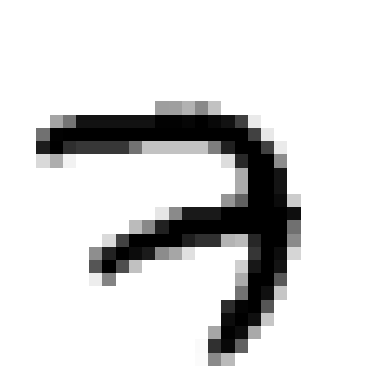

In [76]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a `class_names` array:

In [77]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [78]:
X_valid.shape

(5000, 28, 28)

In [79]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

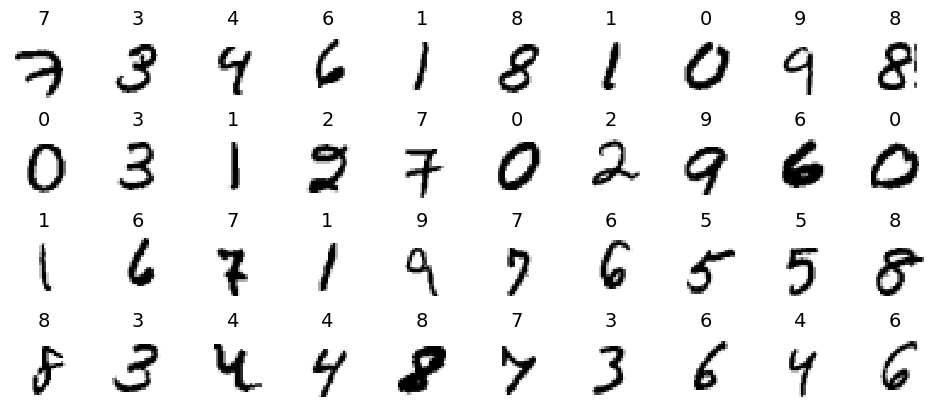

In [80]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [81]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    """Keras Callback that exponentially increases the optimizer's learning rate after each batch.

    This callback multiplies the optimizer's current learning rate by the provided `factor`
    at the end of every training batch. It records the learning rates and corresponding
    batch losses in the `rates` and `losses` lists, respectively. This is useful for
    performing a learning rate range test to identify a suitable learning rate.

    Args:
        factor (float): Multiplicative factor to apply to the learning rate each batch.

    Attributes:
        factor (float): The multiplicative factor provided at construction.
        rates (list[float]): Logged learning rates after each batch.
        losses (list[float]): Logged training losses after each batch.
    """
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [82]:
import numpy as np

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [83]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [84]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [85]:
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6127 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


In [86]:
for rate, loss in zip(expon_lr.rates, expon_lr.losses):
    print(f"{rate:.6f} -> {loss:.4f}")

0.001005 -> 2.4799
0.001010 -> 2.3972
0.001015 -> 2.3918
0.001020 -> 2.3746
0.001025 -> 2.3729
0.001030 -> 2.3659
0.001036 -> 2.3663
0.001041 -> 2.3608
0.001046 -> 2.3601
0.001051 -> 2.3621
0.001056 -> 2.3538
0.001062 -> 2.3513
0.001067 -> 2.3436
0.001072 -> 2.3426
0.001078 -> 2.3406
0.001083 -> 2.3449
0.001088 -> 2.3434
0.001094 -> 2.3420
0.001099 -> 2.3422
0.001105 -> 2.3441
0.001110 -> 2.3468
0.001116 -> 2.3431
0.001122 -> 2.3438
0.001127 -> 2.3413
0.001133 -> 2.3423
0.001138 -> 2.3391
0.001144 -> 2.3387
0.001150 -> 2.3388
0.001156 -> 2.3357
0.001161 -> 2.3359
0.001167 -> 2.3376
0.001173 -> 2.3394
0.001179 -> 2.3391
0.001185 -> 2.3378
0.001191 -> 2.3383
0.001197 -> 2.3369
0.001203 -> 2.3383
0.001209 -> 2.3367
0.001215 -> 2.3361
0.001221 -> 2.3362
0.001227 -> 2.3362
0.001233 -> 2.3363
0.001239 -> 2.3361
0.001245 -> 2.3363
0.001252 -> 2.3365
0.001258 -> 2.3365
0.001264 -> 2.3364
0.001270 -> 2.3366
0.001277 -> 2.3372
0.001283 -> 2.3368
0.001290 -> 2.3361
0.001296 -> 2.3354
0.001303 -> 

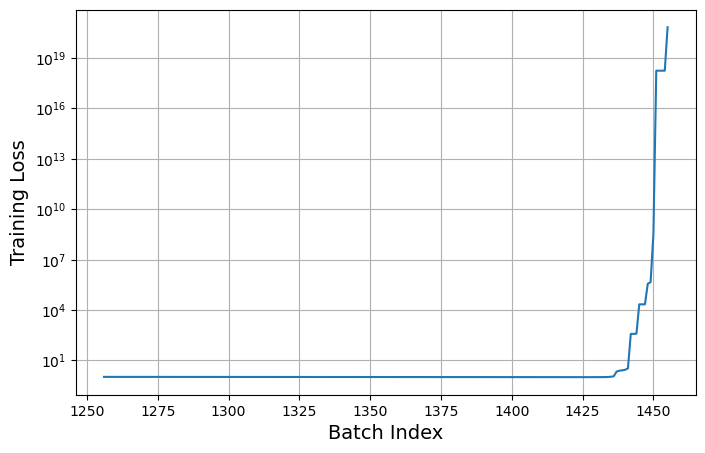

In [87]:
# Safely find batch indices where the loss exceeded the previous finite recorded loss.
losses = np.asarray(expon_lr.losses, dtype=float)
finite_idx = np.flatnonzero(np.isfinite(losses))
lr = np.asarray(expon_lr.rates)

plt.figure(figsize=(8, 5))
plt.plot(finite_idx[-200:], losses[finite_idx[-200:]])
plt.xlabel("Batch Index")
plt.ylabel("Training Loss")
plt.yscale("log")   
plt.grid()
plt.show()

In [88]:
start_idx = 1250
for idx, loss_val, lr_val in zip(finite_idx[start_idx:], losses[finite_idx[start_idx:]], lr[finite_idx[start_idx:]]):
    print(f"Index: {idx:d}, Loss: {loss_val:.6f}, Learning Rate: {lr_val:.6f}")

Index: 1250, Loss: 1.037331, Learning Rate: 0.512559
Index: 1251, Loss: 1.037730, Learning Rate: 0.515121
Index: 1252, Loss: 1.038872, Learning Rate: 0.517697
Index: 1253, Loss: 1.039218, Learning Rate: 0.520286
Index: 1254, Loss: 1.040728, Learning Rate: 0.522887
Index: 1255, Loss: 1.041147, Learning Rate: 0.525501
Index: 1256, Loss: 1.040979, Learning Rate: 0.528129
Index: 1257, Loss: 1.040657, Learning Rate: 0.530770
Index: 1258, Loss: 1.040101, Learning Rate: 0.533423
Index: 1259, Loss: 1.039670, Learning Rate: 0.536091
Index: 1260, Loss: 1.039183, Learning Rate: 0.538771
Index: 1261, Loss: 1.038531, Learning Rate: 0.541465
Index: 1262, Loss: 1.038317, Learning Rate: 0.544172
Index: 1263, Loss: 1.037982, Learning Rate: 0.546893
Index: 1264, Loss: 1.037928, Learning Rate: 0.549627
Index: 1265, Loss: 1.038172, Learning Rate: 0.552376
Index: 1266, Loss: 1.038577, Learning Rate: 0.555137
Index: 1267, Loss: 1.038449, Learning Rate: 0.557913
Index: 1268, Loss: 1.038147, Learning Rate: 0.

We can now plot the loss as a function of the learning rate:

Text(0, 0.5, 'Loss')

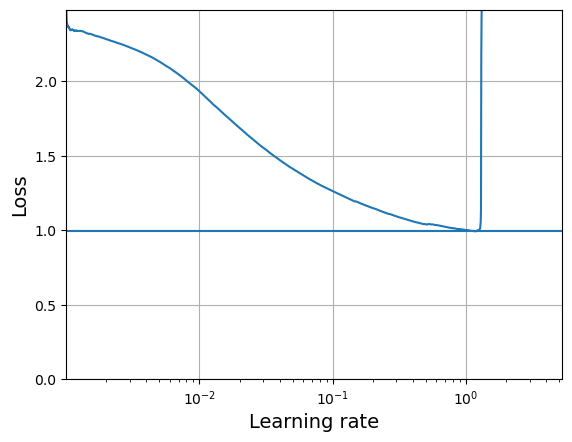

In [89]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [90]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [91]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [92]:
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1) # chosen after LR range test
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [93]:
run_index = 1 # increment this at every run
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)
run_logdir

WindowsPath('my_mnist_logs/run_001')

In [94]:
# Define callbacks: EarlyStopping, ModelCheckpoint, and TensorBoard
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

# Train the model with the defined callbacks
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9271 - loss: 0.2312 - val_accuracy: 0.9720 - val_loss: 0.1033
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9727 - loss: 0.0911 - val_accuracy: 0.9720 - val_loss: 0.0931
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9825 - loss: 0.0577 - val_accuracy: 0.9740 - val_loss: 0.0876
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9866 - loss: 0.0421 - val_accuracy: 0.9786 - val_loss: 0.0811
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9893 - loss: 0.0326 - val_accuracy: 0.9762 - val_loss: 0.0844
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9914 - loss: 0.0272 - val_accuracy: 0.9748 - val_loss: 0.0981
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9923 - loss: 0.0229 - val_accuracy: 0.9794 - val_loss: 0.0841
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9928 - loss: 0

In [95]:
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback to best model
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0753


[0.07534147799015045, 0.9779999852180481]

We got over 98% accuracy. Finally, let's look at the learning curves using TensorBoard:

In [96]:
%tensorboard --logdir=./my_mnist_logs

UsageError: Line magic function `%tensorboard` not found.


---
### Use Keras Tuner to find even better hyperparameters!

In [111]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [120]:
import keras_tuner as kt

def build_model(hp: kt.HyperParameters) -> tf.keras.Model:
    """Build a Keras Sequential model whose hyperparameters are controlled by
    the Keras Tuner `hp` object.

    The tuner will vary:
      - n_hidden: number of hidden Dense layers (0-8)
      - n_neurons: number of neurons per hidden layer (16-256)
      - learning_rate: optimizer learning rate (log-uniform between 1e-4 and 1e-2)
      - optimizer: 'sgd' or 'adam'
    """
    # Define hyperparameters using the `hp` object
    # Number of hidden layers (0-8)
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    # Number of neurons per hidden layer
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    # Learning rate sampled logarithmically between 1e-3 and 1
    learning_rate = hp.Float("learning_rate", min_value=1e-3, max_value=1,
                             sampling="log")
    # Optimizer choice between SGD and Adam
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"]) 
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Construct the Keras Sequential model
    model = tf.keras.Sequential()
    # Flatten 2D images to 1D vectors
    model.add(tf.keras.layers.Flatten())
    # Add the chosen number of hidden Dense layers with ReLU activation
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    # Output layer for 10 classes with softmax
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model

In [121]:
# Create a RandomSearch tuner that maximizes validation accuracy.
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_mnist", project_name="my_rnd_search", seed=42)

# Run the search: each trial trains a candidate model and evaluates on the validation set
random_search_tuner.search(X_train, y_train, epochs=10,
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 30s]
val_accuracy: 0.9692000150680542

Best val_accuracy So Far: 0.9769999980926514
Total elapsed time: 00h 02m 27s


In [122]:
random_search_tuner.get_best_hyperparameters(num_trials=1)[0].values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.04410354359965501,
 'optimizer': 'sgd'}

In [123]:
best_rnd_model = random_search_tuner.get_best_models(num_models=1)[0]

In [124]:
best_rnd_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,110 (547.30 KB)

 Trainable params: 140,110 (547.30 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
best_rnd_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0924


[0.0924266129732132, 0.9769999980926514]